In [35]:
import sys
sys.path.append("..")
from scripts.xarray_utils import (
    analyze_netcdf,
    zarr_to_netcdf,
    find_missing_days,
)
import pandas as pd
import xarray as xr
import numpy as np
import sklearn as sk
import sklearn as sk

In [36]:
# Open the Zarr dataset
ds_imd = xr.open_zarr("/Users/abhimanyu/Desktop/s2s/data/raw/IMD_rainfall_0p25.zarr")
ds_imd = ds_imd.where(ds_imd != -999)

analyze_netcdf("/Users/abhimanyu/Desktop/s2s/data/raw/IMD_rainfall_0p25.nc")

Analysis for NetCDF File: /Users/abhimanyu/Desktop/s2s/data/raw/IMD_rainfall_0p25.nc

--- Dimensions ---
time: 31046
lat: 129
lon: 135

--- Coordinates ---
- lat:
    dtype: float64
    shape: (129,)
    attributes: {'axis': 'Y', 'long_name': 'latitude', 'standard_name': 'latitude', 'units': 'degrees_north'}
- lon:
    dtype: float64
    shape: (135,)
    attributes: {'axis': 'X', 'long_name': 'longitude', 'standard_name': 'longitude', 'units': 'degrees_east'}
- time:
    dtype: datetime64[ns]
    shape: (31046,)
    attributes: {'long_name': 'time', 'standard_name': 'time'}

--- Data Variables ---
- rain:
    dtype: float64
    shape: (31046, 129, 135)
    dimensions: ('time', 'lat', 'lon')
    attributes: {'long_name': 'Rainfall', 'units': 'mm/day'}

--- Global Attributes ---
Conventions: CF-1.7
comment: 
crs: epsg:4326
history: 2026-06-19 06:45:25.930728 Python
references: 
source: https://imdpune.gov.in/
title: IMD gridded data



In [37]:
# Open the Zarr dataset
ds_ecm = xr.open_zarr("/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_sorted.zarr")

analyze_netcdf("/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_sorted.nc")

Analysis for NetCDF File: /Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_sorted.nc

--- Dimensions ---
time: 3720
step: 43
lat: 33
lon: 35

--- Coordinates ---
- lat:
    dtype: float64
    shape: (33,)
    attributes: {'long_name': 'latitude', 'standard_name': 'latitude', 'stored_direction': 'decreasing', 'units': 'degrees_north'}
- lon:
    dtype: float64
    shape: (35,)
    attributes: {'long_name': 'longitude', 'standard_name': 'longitude', 'units': 'degrees_east'}
- step:
    dtype: int64
    shape: (43,)
- time:
    dtype: datetime64[ns]
    shape: (3720,)
    attributes: {'long_name': 'initial time of forecast', 'standard_name': 'forecast_reference_time'}

--- Data Variables ---
- 10m_u_component_of_wind:
    dtype: float32
    shape: (3720, 43, 33, 35)
    dimensions: ('time', 'step', 'lat', 'lon')
    attributes: {'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(35), 'GRIB_Ny': np.int64(33), 'GRIB_cfName': 'eastward_wind', 'GRIB_cfVarName': 'u10', 'GRIB_dataType': 'cf'

In [38]:
# import xarray as xr

# # 1. Open datasets
# ds_ecmv = xr.open_zarr("s2s_reforecast.zarr")
# ds_new = xr.open_zarr("/Users/abhimanyu/Downloads/IFS_reforecast_download-main/s2s_new_vars.zarr")

# print("Original ds_ecmv variables:", list(ds_ecmv.data_vars))
# print("New variables to add:", list(ds_new.data_vars))

# # 2. Align time coordinates (reindex ds_new to match ds_ecmv's chronological order)
# ds_new_aligned = ds_new.reindex(time=ds_ecmv.time)

# # 3. Spatial alignment (interpolate new vars to ds_ecmv's lat/lon grid)
# ds_new_interp = ds_new_aligned.interp(lat=ds_ecmv.lat, lon=ds_ecmv.lon)

# # 4. Merge into a single dataset (now has 14 variables)
# ds_combined = xr.merge([ds_ecmv, ds_new_interp])

# print("\nMerged Dataset:")
# print(ds_combined)

# # 5. Optional: Save merged dataset to a new Zarr store
# # ds_combined.to_zarr("s2s_reforecast_combined.zarr", mode="w")


In [39]:

# convert lead days into timedeltas
step_td = pd.to_timedelta(ds_ecm.step.values, unit="D").to_numpy()

ds_ecmv = ds_ecm.assign_coords(
    valid_time=(("time", "step"),
                ds_ecm.time.values[:, None] + step_td[None, :])
)

In [40]:
# ======================================================================
# S2S multi-window UNet -- LOSS-FAMILY SWEEP VERSION
# Single-cell Jupyter script. Set LOSS_NAME below, run, compare.
#
# Losses available (all masked, all anomaly-space):
#   "mse"          plain masked MSE                     -> conditional MEAN
#   "mae"          masked L1                            -> conditional MEDIAN
#   "huber"        smooth-L1, delta-tunable             -> robust mean/median blend
#   "wmse"         intensity-weighted MSE (Chandel-style extremes weighting)
#   "tail"         tail-weighted: MSE * (1 + a*|y|/std)^p
#   "pinball"      asymmetric quantile loss at one tau (median-ish, tilted)
#   "logcosh"      smooth, MAE-like tails, MSE-like centre
#   "grad"         MSE + spatial-gradient matching (structure, not amplitude)
#   "spectral"     MSE + radial power-spectrum matching (sharpness/structure)
#
# NOTE ON EXPECTATIONS: mse/mae/huber/wmse/tail/pinball/logcosh are all
# POINTWISE -- each converges to some conditional central statistic, so they
# tend to sit on the same skill/ACC frontier and mostly trade WHICH errors
# they tolerate, not how much total signal they extract. "grad" and
# "spectral" are the two that score spatial STRUCTURE rather than per-cell
# error, so they are the ones with a mechanism to move skill and ACC
# together. Run them last if the pointwise family disappoints.
# ======================================================================


# decorator+imports+Args


In [41]:

import os, time, json
from contextlib import contextmanager
import numpy as np

# ---------------- CONFIG ----------------
LOSS_NAME = "mae"          # <-- change this per run
LOSS_KW = {}               # per-loss knobs, e.g. {"delta": 1.0} for huber
                           #   huber   : delta (default 1.0)
                           #   wmse    : power (default 1.0)
                           #   tail    : alpha (default 1.0), power (default 1.0)
                           #   pinball : tau (default 0.5)
                           #   grad    : w_grad (default 1.0)
                           #   spectral: w_spec (default 1.0)

IMD_TARGET_VAR = "rain"
WINDOWS = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
CLIM_WINDOW_DAYS = 7
COARSE_PAD = 3.0
MONTHS = None
TEST_YEARS_N = 3
CACHE = "/Users/abhimanyu/Desktop/s2s/data/cache/unet_cache_mw.npz"
DTYPE = np.float32

class Args:
    cmd = "prepare"          # "prepare" or "train"
    epochs = 60
    batch = 16
    base = 24
    drop = 0.2
    wd = 1e-3
    lr = 2e-4
    patience = 10
    folds = 5

args = Args()
ARG_DICT = {k: getattr(args, k) for k in dir(args) if not k.startswith("_")}
ARG_DICT["loss"] = LOSS_NAME
ARG_DICT["loss_kw"] = LOSS_KW

# separate outputs per loss so runs never collide or resume each other
tag = LOSS_NAME + ("_" + "_".join(f"{k}{v}" for k, v in LOSS_KW.items()) if LOSS_KW else "")
OUT_MAPS = f"unet_mw_{tag}.nc"


@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)



# prepare

In [42]:
# ======================================================================
# PREPARE
# ======================================================================

def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


def _doy_matrix(doys, window, n_doy=366):
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    return (np.minimum(d, n_doy - d) <= window).astype(DTYPE)


def _clim_grid(values, doys, window):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    M = _doy_matrix(doys, window)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        clim = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return clim.reshape((366,) + shp).astype(DTYPE)


def prepare(ecmwf_ds, imd_ds, cache_path):
    import xarray as xr
    from dask.diagnostics import ProgressBar

    with stage("Coarse subset over padded India box"):
        ecmwf_ds = ensure_valid_time(ecmwf_ds)
        for c in ("lat", "lon"):
            if ecmwf_ds[c].values[0] > ecmwf_ds[c].values[-1]:
                ecmwf_ds = ecmwf_ds.sortby(c)
        la0, la1 = float(imd_ds.lat.min()), float(imd_ds.lat.max())
        lo0, lo1 = float(imd_ds.lon.min()), float(imd_ds.lon.max())
        sub = ecmwf_ds.sel(lat=slice(la0 - COARSE_PAD, la1 + COARSE_PAD),
                           lon=slice(lo0 - COARSE_PAD, lo1 + COARSE_PAD))
        if MONTHS is not None:
            sub = sub.sel(time=sub["time"].dt.month.isin(list(MONTHS)))
        feature_vars = list(sub.data_vars)
        clat, clon = sub["lat"].values, sub["lon"].values
        leads = (sub["step"].values / np.timedelta64(1, "D")).astype(int)
        init = sub["time"].values
        print(f"    {dict(sub.sizes)} x {len(feature_vars)} vars")

    imd = imd_ds[IMD_TARGET_VAR]
    imd = imd.assign_coords(time=imd["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    X_list, y_list, doy_list, wid_list = [], [], [], []
    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        with stage(f"Window {wname} (days {lo}-{hi})"):
            sel = np.where((leads >= lo) & (leads <= hi))[0]
            if len(sel) == 0:
                raise ValueError(f"no leads in [{lo},{hi}]")
            with ProgressBar():
                #caluclate mean
                Xw = sub.isel(step=sel).mean(dim="step").compute()
            Xa = np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE)
            windows= Xa.shape[1]
            n_samples, n_vars, h, w = Xa.shape
            K = len(WINDOWS)
            X_rolling = np.zeros((n_samples, K * n_vars, h, w), dtype=DTYPE)
    #         for i in range(n_samples):
    #             w_idx = wid[i]  # Current window index (0 for Week 1, 1 for Week 2, etc.)
    
    # # Fill channels cumulatively up to the current window
    # # Week 1 fills 0:5
    # # Week 2 fills 0:10
    # # Week 3 fills 0:15...
    #             for w in range(w_idx + 1):
    #                 X_rolling[i, w*n_vars : (w+1)*n_vars] = Xa[i, w]
            X_rolling[:, : (wid + 1) * n_vars, :, :] = np.tile(Xa, (1, wid + 1, 1, 1))
            vt = sub["valid_time"].isel(step=sel).dt.floor("D").values
            with ProgressBar():
                y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
            yr = y_all.reshape(vt.shape + y_all.shape[1:])
            ya = np.where(np.isfinite(yr).any(axis=1),np.nansum(yr, axis=1), np.nan)
            centre = init + np.timedelta64((lo + hi) // 2, "D")
            doya = xr.DataArray(centre, dims="t").dt.dayofyear.values
            X_list.append(X_rolling); y_list.append(ya)
            doy_list.append(doya); wid_list.append(np.full(len(Xa), wid, dtype=np.int64))
            print(f"    +{len(Xa)} samples")

    X = np.concatenate(X_list); y = np.concatenate(y_list)
    doy = np.concatenate(doy_list); wid = np.concatenate(wid_list)
    year = np.concatenate([init.astype("datetime64[Y]").astype(int) + 1970] * len(WINDOWS))
    print(f"\n    total {len(X)} samples ({len(init)} inits x {len(WINDOWS)} windows)")

    with stage("Strict mask + test-year holdout"):
        mask = np.isfinite(y).all(axis=0)
        print(f"    strict mask: {int(mask.sum())} cells")
        uy = np.unique(year)
        test_years = set(uy[-TEST_YEARS_N:])
        is_test = np.isin(year, list(test_years))
        print(f"    test years: {sorted(test_years)}")

    with stage("Caching"):
        np.savez_compressed( 
            cache_path, X=X, y=y, doy=doy, wid=wid, year=year,
            mask=mask, is_test=is_test, clat=clat, clon=clon,
            flat_lat=flat_lat, flat_lon=flat_lon,
            feature_vars=np.array(feature_vars),
            window_names=np.array([w[0] for w in WINDOWS]))
        print(f"    {os.path.getsize(cache_path)/1e9:.2f} GB -> {cache_path}")


def anomalise_fold(X, y, doy, tr):
    """Train-fold-only climatology + standardisation. Leakage-critical."""
    clim_y = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    clim_X = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    ya = y - clim_y[doy - 1]
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.nanstd(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.where(xs < 1e-8, 1.0, xs)
    Xa = np.nan_to_num((Xa - xm) / xs)
    return Xa.astype(DTYPE), ya.astype(DTYPE), clim_y


#run the prepare dataset
prepare(ds_ecmv, ds_imd, CACHE)

[ ] Coarse subset over padded India box ...
    step is int64 (max 42) -> units='D'
    {'time': 3720, 'step': 43, 'lat': 33, 'lon': 35} x 21 vars
[x] Coarse subset over padded India box  (0.0s)
[ ] Window week2 (days 8-14) ...
[########################################] | 100% Completed | 6.06 sms
[########################################] | 100% Completed | 1.05 sms
    +3720 samples
[x] Window week2 (days 8-14)  (9.2s)
[ ] Window week3_4 (days 15-28) ...
[########################################] | 100% Completed | 6.61 sms
[########################################] | 100% Completed | 2.60 sms
    +3720 samples
[x] Window week3_4 (days 15-28)  (15.6s)
[ ] Window week5_6 (days 29-42) ...
[########################################] | 100% Completed | 6.38 sms
[########################################] | 100% Completed | 2.92 sms


KeyboardInterrupt: 

In [43]:
#  ======================================================================
# PREPARE
# ======================================================================

def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


def _doy_matrix(doys, window, n_doy=366):
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    return (np.minimum(d, n_doy - d) <= window).astype(DTYPE)


def _clim_grid(values, doys, window):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    M = _doy_matrix(doys, window)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        clim = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return clim.reshape((366,) + shp).astype(DTYPE)


def prepare(ecmwf_ds, imd_ds, cache_path):
    import xarray as xr
    from dask.diagnostics import ProgressBar

    with stage("Coarse subset over padded India box"):
        ecmwf_ds = ensure_valid_time(ecmwf_ds)
        for c in ("lat", "lon"):
            if ecmwf_ds[c].values[0] > ecmwf_ds[c].values[-1]:
                ecmwf_ds = ecmwf_ds.sortby(c)
        la0, la1 = float(imd_ds.lat.min()), float(imd_ds.lat.max())
        lo0, lo1 = float(imd_ds.lon.min()), float(imd_ds.lon.max())
        sub = ecmwf_ds.sel(lat=slice(la0 - COARSE_PAD, la1 + COARSE_PAD),
                           lon=slice(lo0 - COARSE_PAD, lo1 + COARSE_PAD))
        if MONTHS is not None:
            sub = sub.sel(time=sub["time"].dt.month.isin(list(MONTHS)))
        feature_vars = list(sub.data_vars)
        clat, clon = sub["lat"].values, sub["lon"].values
        leads = (sub["step"].values / np.timedelta64(1, "D")).astype(int)
        init = sub["time"].values
        print(f"    {dict(sub.sizes)} x {len(feature_vars)} vars")

    imd = imd_ds[IMD_TARGET_VAR]
    imd = imd.assign_coords(time=imd["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    X_list, y_list, doy_list, wid_list = [], [], [], []
    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        with stage(f"Window {wname} (days {lo}-{hi})"):
            sel = np.where((leads >= lo) & (leads <= hi))[0]
            if len(sel) == 0:
                raise ValueError(f"no leads in [{lo},{hi}]")
            with ProgressBar():
                Xw = sub.isel(step=sel).mean(dim="step").compute()
            Xa = np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE)
            vt = sub["valid_time"].isel(step=sel).dt.floor("D").values
            with ProgressBar():
                y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
            ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)
            centre = init + np.timedelta64((lo + hi) // 2, "D")
            doya = xr.DataArray(centre, dims="t").dt.dayofyear.values
            X_list.append(Xa); y_list.append(ya)
            doy_list.append(doya); wid_list.append(np.full(len(Xa), wid, dtype=np.int64))
            print(f"    +{len(Xa)} samples")

    X = np.concatenate(X_list); y = np.concatenate(y_list)
    doy = np.concatenate(doy_list); wid = np.concatenate(wid_list)
    year = np.concatenate([init.astype("datetime64[Y]").astype(int) + 1970] * len(WINDOWS))
    print(f"\n    total {len(X)} samples ({len(init)} inits x {len(WINDOWS)} windows)")

    with stage("Strict mask + test-year holdout"):
        mask = np.isfinite(y).all(axis=0)
        print(f"    strict mask: {int(mask.sum())} cells")
        uy = np.unique(year)
        test_years = set(uy[-TEST_YEARS_N:])
        is_test = np.isin(year, list(test_years))
        print(f"    test years: {sorted(test_years)}")

    with stage("Caching"):
        np.savez_compressed(
            cache_path, X=X, y=y, doy=doy, wid=wid, year=year,
            mask=mask, is_test=is_test, clat=clat, clon=clon,
            flat_lat=flat_lat, flat_lon=flat_lon,
            feature_vars=np.array(feature_vars),
            window_names=np.array([w[0] for w in WINDOWS]))
        print(f"    {os.path.getsize(cache_path)/1e9:.2f} GB -> {cache_path}")


def anomalise_fold(X, y, doy, tr):
    """Train-fold-only climatology + standardisation. Leakage-critical."""
    clim_y = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    clim_X = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    ya = y - clim_y[doy - 1]
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.nanstd(Xa[tr], axis=(0, 2, 3), keepdims=True)
    xs = np.where(xs < 1e-8, 1.0, xs)
    Xa = np.nan_to_num((Xa - xm) / xs)
    return Xa.astype(DTYPE), ya.astype(DTYPE), clim_y

def precompute_year_partials(X, y, doy, year, window):
    """One-time cost: per-year DOY-weighted sums & counts for X and y."""
    X_flat = X.reshape(len(X), -1)
    y_flat = y.reshape(len(y), -1)
    partials = {}
    for yr in np.unique(year):
        idx = year == yr
        M = _doy_matrix(doy[idx], window)          # (366, n_yr)
        xv, yv = X_flat[idx], y_flat[idx]
        partials[int(yr)] = (
            M @ np.nan_to_num(xv).astype(DTYPE),   # x_sums   (366, px_x)
            M @ np.isfinite(xv).astype(DTYPE),      # x_counts
            M @ np.nan_to_num(yv).astype(DTYPE),    # y_sums   (366, px_y)
            M @ np.isfinite(yv).astype(DTYPE),      # y_counts
        )
    return partials


def anomalise_fold_fast(X, y, doy, tr_mask, year, partials):
    """Same as anomalise_fold but assembles climatology from precomputed partials."""
    tr_years = set(year[tr_mask].tolist())

    # combine training-year partials by simple addition
    xs = xc = ys = yc = None
    for yr in tr_years:
        pxs, pxc, pys, pyc = partials[yr]
        if xs is None:
            xs, xc, ys, yc = pxs.copy(), pxc.copy(), pys.copy(), pyc.copy()
        else:
            xs += pxs; xc += pxc; ys += pys; yc += pyc

    with np.errstate(invalid="ignore", divide="ignore"):
        clim_X = np.where(xc > 0, xs / np.maximum(xc, 1), np.nan)
        clim_y = np.where(yc > 0, ys / np.maximum(yc, 1), np.nan)
    clim_X = clim_X.reshape((366,) + X.shape[1:]).astype(DTYPE)
    clim_y = clim_y.reshape((366,) + y.shape[1:]).astype(DTYPE)

    ya = y - clim_y[doy - 1]
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[tr_mask], axis=(0, 2, 3), keepdims=True)
    xs2 = np.nanstd(Xa[tr_mask], axis=(0, 2, 3), keepdims=True)
    xs2 = np.where(xs2 < 1e-8, 1.0, xs2)
    Xa = np.nan_to_num((Xa - xm) / xs2)
    return Xa.astype(DTYPE), ya.astype(DTYPE), clim_y

#run the prepare dataset
prepare(ds_ecmv, ds_imd, CACHE)

[ ] Coarse subset over padded India box ...
    step is int64 (max 42) -> units='D'
    {'time': 3720, 'step': 43, 'lat': 33, 'lon': 35} x 21 vars
[x] Coarse subset over padded India box  (0.0s)
[ ] Window week2 (days 8-14) ...
[########################################] | 100% Completed | 5.72 sms
[########################################] | 100% Completed | 1.16 sms
    +3720 samples
[x] Window week2 (days 8-14)  (9.3s)
[ ] Window week3_4 (days 15-28) ...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_62194/1193751896.py:83: RuntimeWarning: Mean of empty slice
  ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)


[########################################] | 100% Completed | 5.93 sms
[########################################] | 100% Completed | 2.22 sms
    +3720 samples
[x] Window week3_4 (days 15-28)  (14.3s)
[ ] Window week5_6 (days 29-42) ...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_62194/1193751896.py:83: RuntimeWarning: Mean of empty slice
  ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)


[########################################] | 100% Completed | 6.02 sms
[########################################] | 100% Completed | 2.19 sms
    +3720 samples
[x] Window week5_6 (days 29-42)  (13.9s)


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_62194/1193751896.py:83: RuntimeWarning: Mean of empty slice
  ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)



    total 11160 samples (3720 inits x 3 windows)
[ ] Strict mask + test-year holdout ...
    strict mask: 4964 cells
    test years: [np.int64(2022), np.int64(2023), np.int64(2024)]
[x] Strict mask + test-year holdout  (0.1s)
[ ] Caching ...
    1.06 GB -> /Users/abhimanyu/Desktop/s2s/data/cache/unet_cache_mw.npz
[x] Caching  (27.6s)


In [44]:

# ======================================================================
# LOSS FAMILY
# ======================================================================

def make_loss(name, target_std, **kw):
    """Return fn(pred, target, mask) -> scalar. All masked, all normalised
    by mask.sum() (never numel), all operating on anomalies.

    target_std: scalar float, train-set anomaly std. Used to make the
    intensity-weighted variants scale-free so their knobs mean the same
    thing regardless of units.
    """
    import torch
    import torch.nn.functional as F

    def _m(x, m):
        """mask, sum, normalise by mask -- the one correct reduction."""
        return (x * m).sum() / m.sum().clamp(min=1.0)

    if name == "mse":
        def f(p, t, m):
            return _m((p - t) ** 2, m)


    elif name == "mae":
        def f(p, t, m):
            return _m((p - t).abs(), m)

    elif name == "huber":
        delta = kw.get("delta", 1.0)
        def f(p, t, m):
            e = (p - t).abs()
            q = torch.clamp(e, max=delta)
            return _m(0.5 * q ** 2 + delta * (e - q), m)

    elif name == "logcosh":
        def f(p, t, m):
            e = p - t
            # numerically stable log(cosh(e))
            return _m(e + F.softplus(-2.0 * e) - float(np.log(2.0)), m) \
                if False else _m(torch.log(torch.cosh(torch.clamp(e, -12, 12))), m)

    elif name == "wmse":
        # intensity-weighted MSE: weight each cell by how extreme the OBS is.
        # This is the Chandel-style "weighted loss for extremes" idea.
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = 1.0 + (t.abs() / target_std) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "tail":
        # like wmse but with an explicit strength knob; alpha=0 -> plain MSE
        alpha = kw.get("alpha", 1.0)
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = (1.0 + alpha * (t.abs() / target_std)) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "pinball":
        # asymmetric: under-prediction costs tau/(1-tau) more than over.
        # tau=0.5 == MAE/2. tau>0.5 pushes predictions UP (anti-hedge for wet).
        tau = kw.get("tau", 0.5)
        def f(p, t, m):
            e = t - p
            return _m(torch.maximum(tau * e, (tau - 1.0) * e), m)

    elif name == "grad":
        # MSE + spatial-gradient matching. Scores STRUCTURE, not per-cell
        # amplitude, so it has a mechanism the pointwise family lacks.
        wg = kw.get("w_grad", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            mx = m[:, :, 1:] * m[:, :, :-1]
            my = m[:, 1:, :] * m[:, :-1, :]
            gx = ((p[:, :, 1:] - p[:, :, :-1]) - (t[:, :, 1:] - t[:, :, :-1])) ** 2
            gy = ((p[:, 1:, :] - p[:, :-1, :]) - (t[:, 1:, :] - t[:, :-1, :])) ** 2
            return base + wg * (_m(gx, mx) + _m(gy, my))

    elif name == "spectral":
        # MSE + radially-averaged power spectrum matching. Directly targets
        # the "deterministic nets lose power at fine scales" problem.
        ws = kw.get("w_spec", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            pf = torch.fft.rfft2(p * m)
            tf = torch.fft.rfft2(t * m)
            pp = (pf.real ** 2 + pf.imag ** 2 + 1e-8).mean(dim=0)
            tp = (tf.real ** 2 + tf.imag ** 2 + 1e-8).mean(dim=0)
            return base + ws * (torch.log(pp) - torch.log(tp)).abs().mean()

    else:
        raise ValueError(f"unknown LOSS_NAME '{name}'")

    return f


In [45]:
# ======================================================================
# LOSS FAMILY
# ======================================================================

def make_loss(name, target_std, **kw):
    """Return fn(pred, target, mask) -> scalar. All masked, all normalised
    by mask.sum() (never numel), all operating on anomalies.

    target_std: scalar float, train-set anomaly std. Used to make the
    intensity-weighted variants scale-free so their knobs mean the same
    thing regardless of units.
    """
    import torch
    import torch.nn.functional as F

    def _m(x, m):
        """mask, sum, normalise by mask -- the one correct reduction."""
        return (x * m).sum() / m.sum().clamp(min=1.0)

    if name == "mse":
        def f(p, t, m):
            return _m((p - t) ** 2, m)

    elif name == "mae":
        def f(p, t, m):
            return _m((p - t).abs(), m)

    elif name == "huber":
        delta = kw.get("delta", 1.0)
        def f(p, t, m):
            e = (p - t).abs()
            q = torch.clamp(e, max=delta)
            return _m(0.5 * q ** 2 + delta * (e - q), m)

    elif name == "logcosh":
        def f(p, t, m):
            e = p - t
            # numerically stable log(cosh(e))
            return _m(e + F.softplus(-2.0 * e) - float(np.log(2.0)), m) \
                if False else _m(torch.log(torch.cosh(torch.clamp(e, -12, 12))), m)

    elif name == "wmse":
        # intensity-weighted MSE: weight each cell by how extreme the OBS is.
        # This is the Chandel-style "weighted loss for extremes" idea.
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = 1.0 + (t.abs() / target_std) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "tail":
        # like wmse but with an explicit strength knob; alpha=0 -> plain MSE
        alpha = kw.get("alpha", 1.0)
        power = kw.get("power", 1.0)
        def f(p, t, m):
            w = (1.0 + alpha * (t.abs() / target_std)) ** power
            return _m(w * (p - t) ** 2, m)

    elif name == "pinball":
        # asymmetric: under-prediction costs tau/(1-tau) more than over.
        # tau=0.5 == MAE/2. tau>0.5 pushes predictions UP (anti-hedge for wet).
        tau = kw.get("tau", 0.5)
        def f(p, t, m):
            e = t - p
            return _m(torch.maximum(tau * e, (tau - 1.0) * e), m)

    elif name == "grad":
        # MSE + spatial-gradient matching. Scores STRUCTURE, not per-cell
        # amplitude, so it has a mechanism the pointwise family lacks.
        wg = kw.get("w_grad", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            mx = m[:, :, 1:] * m[:, :, :-1]
            my = m[:, 1:, :] * m[:, :-1, :]
            gx = ((p[:, :, 1:] - p[:, :, :-1]) - (t[:, :, 1:] - t[:, :, :-1])) ** 2
            gy = ((p[:, 1:, :] - p[:, :-1, :]) - (t[:, 1:, :] - t[:, :-1, :])) ** 2
            return base + wg * (_m(gx, mx) + _m(gy, my))

    elif name == "spectral":
        # MSE + radially-averaged power spectrum matching. Directly targets
        # the "deterministic nets lose power at fine scales" problem.
        ws = kw.get("w_spec", 1.0)
        def f(p, t, m):
            base = _m((p - t) ** 2, m)
            pf = torch.fft.rfft2(p * m)
            tf = torch.fft.rfft2(t * m)
            pp = (pf.real ** 2 + pf.imag ** 2 + 1e-8).mean(dim=0)
            tp = (tf.real ** 2 + tf.imag ** 2 + 1e-8).mean(dim=0)
            return base + ws * (torch.log(pp) - torch.log(tp)).abs().mean()

    else:
        raise ValueError(f"unknown LOSS_NAME '{name}'")

    return f

# model

# train

In [27]:
# ======================================================================
# MODEL + TRAIN
# ======================================================================
args.cmd = "train"

def build_and_run(args, cache_path, out_maps, loss_name, loss_kw):
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"    device: {dev} | loss: {loss_name} {loss_kw}")

    z = np.load(cache_path, allow_pickle=False)
    X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
    year, mask, is_test = z["year"], z["mask"], z["is_test"]
    clat, clon = z["clat"], z["clon"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    n_win = len(z["window_names"]); H, W = len(flat_lat), len(flat_lon)
    n_var = X.shape[1]

    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    samp_np = np.stack([gxx, gyy], -1).astype(np.float32)[None]
    assert np.abs(samp_np).max() <= 1.0, "fine grid outside coarse box"

    lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
    lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
    static_np = np.stack([mask.astype(DTYPE),
                          np.broadcast_to(lat2, (H, W)).astype(DTYPE),
                          np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]

    def gn(c):
        for g in (8, 4, 2, 1):
            if c % g == 0:
                return nn.GroupNorm(g, c)

    class Block(nn.Module):
        def __init__(self, ci, co, drop=0.0):
            super().__init__()
            L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
                 nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
            if drop > 0:
                L.append(nn.Dropout2d(drop))
            self.f = nn.Sequential(*L)
        def forward(self, x):
            return self.f(x)

    class MWUNet(nn.Module):
        def __init__(self, n_var, n_win, base=24, drop=0.2, emb=4):
            super().__init__()
            self.emb = nn.Embedding(n_win, emb)
            self.enc_c1 = Block(n_var + emb, base * 2)
            self.enc_c2 = Block(base * 2, base * 2)
            self.inp = Block(base * 2 + 3, base)
            self.d1 = Block(base, base * 2, drop)
            self.d2 = Block(base * 2, base * 4, drop)
            self.bott = Block(base * 4, base * 4, drop)
            self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
            self.du2 = Block(base * 4, base * 2, drop)
            self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
            self.du1 = Block(base * 2, base)
            self.head = nn.Conv2d(base, 1, 1)
            self.pool = nn.MaxPool2d(2)
        def forward(self, xc, wid, samp, static):
            b, _, h, w = xc.shape
            e = self.emb(wid)[:, :, None, None].expand(-1, -1, h, w)
            c = self.enc_c2(self.enc_c1(torch.cat([xc, e], 1)))
            f = F.grid_sample(c, samp.expand(b, -1, -1, -1),
                              mode="bilinear", align_corners=True)
            f = torch.cat([f, static.expand(b, -1, -1, -1)], 1)
            H0, W0 = f.shape[-2:]
            f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
            e0 = self.inp(f); e1 = self.d1(self.pool(e0)); e2 = self.d2(self.pool(e1))
            u = self.du2(torch.cat([self.u2(self.bott(e2)), e1], 1))
            u = self.du1(torch.cat([self.u1(u), e0], 1))
            return self.head(u)[:, :, :H0, :W0].squeeze(1)

    samp = torch.tensor(samp_np).to(dev)
    stat = torch.tensor(static_np).to(dev)

    def skill_acc(p, t, fin):
        se_m = np.where(fin, (t - p) ** 2, np.nan)
        se_c = np.where(fin, t ** 2, np.nan)
        with np.errstate(invalid="ignore"):
            rmse_m = np.sqrt(np.namean(se_m, axis=0))
            rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
            ok = rmse_c > 1e-6
            skill = np.where(ok, 1 - rmse_m / np.where(ok, rmse_c, 1), np.nan)
            tm = np.nanmean(np.where(fin, t, np.nan), axis=0)
            pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
            num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
            den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                          * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
            acc = np.where(den > 0, num / den, np.nan)
        return skill, acc

    def std_ratio(p, t, fin):
        """Diagnostic only -- reported, never optimised."""
        pv, tv = p[fin], t[fin]
        return float(pv.std() / tv.std()) if tv.std() > 0 else np.nan

    def train_one(tr_idx, va_idx, Xa, ya, max_epochs):
        Xt = torch.tensor(Xa)
        yt = torch.tensor(np.nan_to_num(ya))
        widt = torch.tensor(wid)
        fin = torch.tensor((np.isfinite(ya) & mask[None]).astype(DTYPE))

        tstd = float(np.nanstd(ya[tr_idx][np.isfinite(ya[tr_idx])]))
        crit = make_loss(loss_name, tstd, **loss_kw)

        def dl(idx, sh):
            return DataLoader(TensorDataset(Xt[idx], widt[idx], yt[idx], fin[idx]),
                              batch_size=args.batch, shuffle=sh)

        tr_dl, va_dl = dl(tr_idx, True), dl(va_idx, False)
        model = MWUNet(n_var, n_win, base=args.base, drop=args.drop).to(dev)
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

        best, best_state, wait = np.inf, None, 0
        for ep in range(max_epochs):
            model.train()
            for xb, wb, yb, mb in tr_dl:
                xb, wb, yb, mb = [t.to(dev) for t in (xb, wb, yb, mb)]
                loss = crit(model(xb, wb, samp, stat), yb, mb)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
            sched.step()

            model.eval()
            vl, n = 0.0, 0
            with torch.no_grad():
                for xb, wb, yb, mb in va_dl:
                    xb, wb, yb, mb = [t.to(dev) for t in (xb, wb, yb, mb)]
                    vl += float(crit(model(xb, wb, samp, stat), yb, mb)) * len(xb)
                    n += len(xb)
            vl /= n
            if vl < best - 1e-6:
                best, wait = vl, 0
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
            else:
                wait += 1
            if wait >= args.patience:
                break
        model.load_state_dict(best_state)
        return model, best, ep + 1

    def predict(model, idx, Xa):
        Xt = torch.tensor(Xa); widt = torch.tensor(wid)
        out = []
        model.eval()
        with torch.no_grad():
            for a in range(0, len(idx), args.batch):
                j = idx[a:a + args.batch]
                out.append(model(Xt[j].to(dev), widt[j].to(dev), samp, stat).cpu().numpy())
        return np.concatenate(out)

    # ---------- rotating-year CV ----------
    nontest_years = sorted(set(year[~is_test].tolist()))
    blocks = np.array_split(nontest_years, args.folds)
    resume_path = out_maps.replace(".nc", "_folds.json")
    done = {}
    if os.path.exists(resume_path):
        with open(resume_path) as fh:
            done = {int(k): v for k, v in json.load(fh).items()}
        print(f"    resuming: folds {sorted(done)} cached ({resume_path})")

    with stage(f"Rotating-year CV: {args.folds} folds over {len(nontest_years)} years"):
        for fi, val_years in enumerate(blocks):
            if fi in done:
                r = done[fi]
                print(f"    fold {fi} (cached): skill {r['skill']:+.3f} | ACC {r['acc']:.3f}")
                continue
            val_years = set(val_years.tolist())
            va_i = np.isin(year, list(val_years)) & ~is_test
            tr_i = ~np.isin(year, list(val_years)) & ~is_test
            Xa, ya, _ = anomalise_fold(X, y, doy, tr_i)
            model, vloss, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0],
                                          Xa, ya, args.epochs)
            p = predict(model, np.where(va_i)[0], Xa)
            t = ya[va_i]
            fin = np.isfinite(y[va_i]) & mask[None]
            sk, ac = skill_acc(p, t, fin)
            ms, ma = float(np.nanmean(sk[mask])), float(np.nanmean(ac[mask]))
            sr = std_ratio(p, t, fin)
            done[fi] = {"skill": ms, "acc": ma, "std_ratio": sr,
                        "val_years": sorted(val_years), "epochs": int(eps),
                        "vloss": float(vloss)}
            with open(resume_path, "w") as fh:
                json.dump({str(k): v for k, v in done.items()}, fh, indent=2)
            print(f"    fold {fi} val {sorted(val_years)}: skill {ms:+.3f} | "
                  f"ACC {ma:.3f} | std_ratio {sr:.3f} | {eps} ep   [saved]", flush=True)

        ks = [i for i in range(args.folds) if i in done]
        fs = [done[i]["skill"] for i in ks]; fa = [done[i]["acc"] for i in ks]
        fr = [done[i].get("std_ratio", np.nan) for i in ks]
        print(f"\n    [{loss_name}]  CV skill {np.mean(fs):+.4f} +/- {np.std(fs):.4f}"
              f" | CV ACC {np.mean(fa):.4f} +/- {np.std(fa):.4f}"
              f" | std_ratio {np.nanmean(fr):.3f}")

    # ---------- final model -> test ----------
    with stage("Final model on all non-test years -> test"):
        es_years = set(nontest_years[-2:])
        va_i = np.isin(year, list(es_years)) & ~is_test
        fit_i = (~is_test) & ~va_i
        Xa, ya, _ = anomalise_fold(X, y, doy, fit_i)
        model, _, eps = train_one(np.where(fit_i)[0], np.where(va_i)[0], Xa, ya, args.epochs)

        te_i = np.where(is_test)[0]
        p = predict(model, te_i, Xa)
        t = ya[is_test]
        fin = np.isfinite(y[is_test]) & mask[None]

        import xarray as xr
        wid_te = wid[is_test]; data_vars = {}
        print(f"    trained {eps} ep")
        summary = {}
        for w in range(n_win):
            sm = wid_te == w
            if sm.sum() == 0:
                continue
            sk, ac = skill_acc(p[sm], t[sm], fin[sm])
            sr = std_ratio(p[sm], t[sm], fin[sm])
            wn = str(z["window_names"][w])
            data_vars[f"{wn}_skill"] = (("lat", "lon"), sk)
            data_vars[f"{wn}_acc"] = (("lat", "lon"), ac)
            summary[wn] = {"skill": float(np.nanmean(sk[mask])),
                           "acc": float(np.nanmean(ac[mask])),
                           "std_ratio": sr,
                           "pct_pos": float(100 * np.nanmean(sk[mask] > 0))}
            print(f"    test {wn:>8}: skill {summary[wn]['skill']:+.4f} | "
                  f"ACC {summary[wn]['acc']:.4f} | std_ratio {sr:.3f} | "
                  f"{summary[wn]['pct_pos']:.0f}% cells+")

        out = xr.Dataset(data_vars, coords={"lat": flat_lat, "lon": flat_lon})
        out.attrs["loss"] = f"{loss_name} {loss_kw}"
        out.attrs["windows"] = ", ".join(f"{n}:{lo}-{hi}" for n, lo, hi in WINDOWS)
        out.to_netcdf(out_maps)
        torch.save({"state": model.state_dict(), "args": ARG_DICT}, out_maps.replace(".nc", ".pt"))

        # append to a cross-loss comparison table
        tbl = "loss_comparison.json"
        allr = json.load(open(tbl)) if os.path.exists(tbl) else {}
        allr[tag] = {"cv_skill": float(np.mean(fs)), "cv_acc": float(np.mean(fa)),
                     "cv_std_ratio": float(np.nanmean(fr)), "test": summary}
        json.dump(allr, open(tbl, "w"), indent=2)
        print(f"    -> {out_maps} (+ .pt); comparison appended to {tbl}")


# ======================================================================
if args.cmd == "prepare":
    prepare(ds_ecmv, ds_imd, CACHE)          # noqa: F821
else:
    if not os.path.exists(CACHE):
        raise SystemExit(f"run prepare first ({CACHE} missing)")
    build_and_run(args, CACHE, OUT_MAPS, LOSS_NAME, LOSS_KW)

    # print the running cross-loss comparison
    tbl = "loss_comparison.json"
    if os.path.exists(tbl):
        allr = json.load(open(tbl))
        print(f"\n{'loss':>22} {'CV skill':>10} {'CV ACC':>8} {'std':>6} "
              f"{'w3_4 skill':>11} {'w3_4 ACC':>9}")
        for k, v in sorted(allr.items()):
            w = v["test"].get("week3_4", {})
            print(f"{k:>22} {v['cv_skill']:>+10.4f} {v['cv_acc']:>8.4f} "
                  f"{v['cv_std_ratio']:>6.3f} {w.get('skill', float('nan')):>+11.4f} "
                  f"{w.get('acc', float('nan')):>9.4f}")

    device: mps | loss: mae {}
[ ] Rotating-year CV: 5 folds over 17 years ...


KeyboardInterrupt: 

In [31]:
"""
Three-line comparison per window: ECMWF forecast vs UNet vs observed IMD.

Plots the India-mean anomaly time series over the test years, one line each:
    observed IMD, raw ECMWF, UNet.

Anomalies (each minus its own seasonal climatology), because raw ECMWF tp and
IMD rain are in different units -- anomalies put all three on one axis.

Reads the same cache + checkpoint. No retraining.
  python s2s_threeline.py
"""

import argparse
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

DTYPE = np.float32
CLIM_WINDOW_DAYS = 7
RAW_PRECIP_VAR = "total_precipitation"


def _clim(values, doys, window=CLIM_WINDOW_DAYS, n_doy=366):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    M = (np.minimum(d, n_doy - d) <= window).astype(DTYPE)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return c.reshape((n_doy,) + shp).astype(DTYPE)


def unet_predict(args, z, X, y, doy, wid, fit_i, clat, clon, flat_lat, flat_lon, mask):
    import torch, torch.nn as nn, torch.nn.functional as F
    H, W = len(flat_lat), len(flat_lon)
    n_var, n_win = X.shape[1], len(z["window_names"])
    dev = ("mps" if torch.backends.mps.is_available()
           else "cuda" if torch.cuda.is_available() else "cpu")

    clim_X = _clim(X[fit_i], doy[fit_i])
    Xa = X - clim_X[doy - 1]
    xm = np.nanmean(Xa[fit_i], (0, 2, 3), keepdims=True)
    xs = np.nanstd(Xa[fit_i], (0, 2, 3), keepdims=True)
    Xa = np.nan_to_num((Xa - xm) / np.where(xs < 1e-8, 1.0, xs)).astype(DTYPE)

    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    samp = torch.tensor(np.stack([gxx, gyy], -1).astype(np.float32)[None]).to(dev)
    lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
    lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
    static = torch.tensor(np.stack([mask.astype(DTYPE),
        np.broadcast_to(lat2, (H, W)).astype(DTYPE),
        np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]).to(dev)

    ckpt = torch.load(args.ckpt, map_location=dev)
    base, drop = ckpt["args"].get("base", 24), ckpt["args"].get("drop", 0.2)

    def gn(c):
        for g in (8, 4, 2, 1):
            if c % g == 0:
                return nn.GroupNorm(g, c)

    class Block(nn.Module):
        def __init__(self, ci, co, drop=0.0):
            super().__init__()
            L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
                 nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
            if drop > 0:
                L.append(nn.Dropout2d(drop))
            self.f = nn.Sequential(*L)
        def forward(self, x):
            return self.f(x)

    class MWUNet(nn.Module):
        def __init__(self, n_var, n_win, base=24, drop=0.2, emb=4):
            super().__init__()
            self.emb = nn.Embedding(n_win, emb)
            self.enc_c1 = Block(n_var + emb, base * 2)
            self.enc_c2 = Block(base * 2, base * 2)
            self.inp = Block(base * 2 + 3, base)
            self.d1 = Block(base, base * 2, drop)
            self.d2 = Block(base * 2, base * 4, drop)
            self.bott = Block(base * 4, base * 4, drop)
            self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
            self.du2 = Block(base * 4, base * 2, drop)
            self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
            self.du1 = Block(base * 2, base)
            self.head = nn.Conv2d(base, 1, 1)
            self.pool = nn.MaxPool2d(2)
        def forward(self, xc, wid, samp, static):
            b, _, h, w = xc.shape
            e = self.emb(wid)[:, :, None, None].expand(-1, -1, h, w)
            c = self.enc_c2(self.enc_c1(torch.cat([xc, e], 1)))
            f = F.grid_sample(c, samp.expand(b, -1, -1, -1),
                              mode="bilinear", align_corners=True)
            f = torch.cat([f, static.expand(b, -1, -1, -1)], 1)
            H0, W0 = f.shape[-2:]
            f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
            e0 = self.inp(f); e1 = self.d1(self.pool(e0)); e2 = self.d2(self.pool(e1))
            u = self.du2(torch.cat([self.u2(self.bott(e2)), e1], 1))
            u = self.du1(torch.cat([self.u1(u), e0], 1))
            return self.head(u)[:, :, :H0, :W0].squeeze(1)

    model = MWUNet(n_var, n_win, base=base, drop=drop).to(dev)
    model.load_state_dict(ckpt["state"]); model.eval()
    Xt, widt = torch.tensor(Xa), torch.tensor(wid)
    out = []
    with torch.no_grad():
        for a in range(0, len(X), args.batch):
            j = slice(a, a + args.batch)
            out.append(model(Xt[j].to(dev), widt[j].to(dev), samp, static).cpu().numpy())
    return np.concatenate(out)


def main():
    class Args:
        cache = "/Users/abhimanyu/Desktop/s2s/data/cache/unet_cache_mw.npz"
        ckpt = "unet_mw_mae.pt"         # Pointing to the new model checkpoint
        batch = 16
        out = "threeline_mae.png"       # Using a unique file output name
    args = Args()


    z = np.load(args.cache, allow_pickle=False)
    X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
    mask, is_test, year = z["mask"], z["is_test"], z["year"]
    clat, clon = z["clat"], z["clon"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    feature_vars = [str(v) for v in z["feature_vars"]]
    window_names = [str(w) for w in z["window_names"]]
    n_win = len(window_names)
    tp_idx = feature_vars.index(RAW_PRECIP_VAR)
    fit_i = ~is_test

    # raw ECMWF tp on the fine grid
    import xarray as xr
    tp_fine = xr.DataArray(X[:, tp_idx], dims=("s", "lat", "lon"),
                           coords={"lat": clat, "lon": clon}
                           ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)

    # anomalies, each vs its own train climatology
    obs_a = y - _clim(y[fit_i], doy[fit_i])[doy - 1]
    ecm_a = tp_fine - _clim(tp_fine[fit_i], doy[fit_i])[doy - 1]
    unet_a = unet_predict(args, z, X, y, doy, wid, fit_i,
                          clat, clon, flat_lat, flat_lon, mask)

    # India-mean over valid cells, test samples only
    m3 = mask[None]
    def india_mean(a):
        return np.nansum(np.where(m3, a, np.nan) * m3, axis=(1, 2)) / m3.sum()

    fig, axes = plt.subplots(n_win, 1, figsize=(13, 3.2 * n_win), sharex=False)
    axes = np.atleast_1d(axes)
    for w in range(n_win):
        sel = (wid == w) & is_test
        order = np.argsort(np.arange(len(sel))[sel])   # keep chronological-ish
        idx = np.where(sel)[0]
        ax = axes[w]
        t = np.arange(len(idx))
        ax.plot(t, india_mean(obs_a)[idx], "-", color="black", lw=2, label="observed IMD")
        ax.plot(t, india_mean(ecm_a)[idx], "-", color="#888", lw=1.5, label="raw ECMWF")
        ax.plot(t, india_mean(unet_a)[idx], "-", color="#E45756", lw=1.5, label="UNet")
        ax.axhline(0, color="gray", lw=0.5, ls=":")
        r_u = np.corrcoef(india_mean(unet_a)[idx], india_mean(obs_a)[idx])[0, 1]
        r_e = np.corrcoef(india_mean(ecm_a)[idx], india_mean(obs_a)[idx])[0, 1]
        ax.set_title(f"{window_names[w]}  (India-mean anomaly; "
                     f"corr vs obs: UNet {r_u:.2f}, ECMWF {r_e:.2f})")
        ax.set_ylabel("anomaly (mm/day)")
        if w == 0:
            ax.legend(ncol=3, loc="upper right", fontsize=9)
    axes[-1].set_xlabel("test-set forecast index (chronological within window)")
    fig.tight_layout()
    fig.savefig(args.out, dpi=140)
    print(f"-> {args.out}")


if __name__ == "__main__":
    main()


FileNotFoundError: [Errno 2] No such file or directory: 'unet_mw_mae.pt'

In [32]:
ds_big = xr.open_zarr("/Users/abhimanyu/Downloads/IFS_reforecast_download-main/s2s_new_vars_sorted.zarr")

In [46]:
# ======================================================================
# DUAL-ENCODER multi-window UNet -- Jupyter cell.
#
# Two predictor boxes, two encoders, merged at the IMD fine grid:
#   ENCODER A (regional)    : your existing 21 ECMWF vars, current box
#   ENCODER B (large-scale) : OLR + gh200/500/850/1000, bigger box
#                             (-6.5..50 N, 30..120 E) -- captures MJO/BSISO
#                             genesis (equatorward) and the mid-latitude
#                             wave train (poleward) that the regional box
#                             cuts off.
#
# WHY MERGE AT THE FINE GRID, NOT THE BOTTLENECK
# ----------------------------------------------
# The two boxes are different extents on different grids. You cannot concat
# their feature maps directly. Each encoder processes its OWN box at its own
# resolution, then each is grid_sample'd to the shared IMD output grid with
# its OWN sampling grid, and concatenated there. This preserves each
# encoder's spatial reasoning and handles the extent mismatch honestly.
# Merging at the bottleneck (pool -> vector -> concat) would throw away the
# spatial structure that is the whole point of a wider OLR context.
#
# SETUP: run `prepare` once (builds X regional + X_big large-scale, aligned
# to the same inits/windows), then `train`. The OLR/gh zarr must have the
# same (time, step) structure as your ECMWF archive -- you confirmed it does.
#
# ABLATION: this is only meaningful against your single-encoder grad run.
# OLR correlating well ALONE does not guarantee a large gain ON TOP OF tp
# (both track the same convection). The delta vs the single-encoder model
# is the result, small or large.
# ======================================================================

import os, time, json
from contextlib import contextmanager
import numpy as np

# ---------------- CONFIG ----------------
IMD_TARGET_VAR = "rain"
WINDOWS = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
CLIM_WINDOW_DAYS = 7
COARSE_PAD = 3.0
MONTHS = None
TEST_YEARS_N = 3
DTYPE = np.float32

# regional predictors (encoder A) come from your existing ECMWF dataset.
# large-scale predictors (encoder B) come from the OLR/gh dataset.
BIG_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
            "geopotential_height_500", "geopotential_height_850",
            "geopotential_height_1000"]

CACHE = "unet_cache_dual.npz"

class Args:
    cmd = "prepare"
    epochs = 60
    batch = 16
    base = 24
    drop = 0.2
    wd = 1e-3
    lr = 2e-4
    patience = 10
    folds = 5

args = Args()
ARG_DICT = {k: getattr(args, k) for k in dir(args) if not k.startswith("_")}
OUT_MAPS = "unet_dual.nc"


@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)


# ======================================================================
# PREPARE  (two boxes -> two arrays, aligned to the SAME inits/windows)
# ======================================================================

def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


def _doy_matrix(doys, window, n_doy=366):
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    return (np.minimum(d, n_doy - d) <= window).astype(DTYPE)


def _clim_grid(values, doys, window):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    M = _doy_matrix(doys, window)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        clim = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return clim.reshape((366,) + shp).astype(DTYPE)


def _prep_box(sub, feature_vars, imd, flat_lat, flat_lon, leads, init):
    """Window-aggregate one dataset's predictors + IMD target. Returns
    stacked-per-window (X, y, doy, wid) lists. IMD target is identical across
    boxes (same valid dates), so we recompute it here but only keep box A's."""
    import xarray as xr
    from dask.diagnostics import ProgressBar
    Xl, yl, dl, wl = [], [], [], []
    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        sel = np.where((leads >= lo) & (leads <= hi))[0]
        if len(sel) == 0:
            raise ValueError(f"no leads in [{lo},{hi}]")
        with ProgressBar():
            Xw = sub.isel(step=sel).mean(dim="step").compute()
        Xa = np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE)
        vt = sub["valid_time"].isel(step=sel).dt.floor("D").values
        with ProgressBar():
            y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
        ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)
        centre = init + np.timedelta64((lo + hi) // 2, "D")
        doya = xr.DataArray(centre, dims="t").dt.dayofyear.values
        Xl.append(Xa); yl.append(ya); dl.append(doya)
        wl.append(np.full(len(Xa), wid, dtype=np.int64))
    return Xl, yl, dl, wl


def _subset_box(ds, imd, pad):
    """Crop a predictor dataset to the padded IMD box (for encoder A) or leave
    it as-is (encoder B, already a chosen box). Sorts ascending lat/lon."""
    ds = ensure_valid_time(ds)
    for c in ("lat", "lon"):
        if ds[c].values[0] > ds[c].values[-1]:
            ds = ds.sortby(c)
    if pad is not None:
        la0, la1 = float(imd.lat.min()), float(imd.lat.max())
        lo0, lo1 = float(imd.lon.min()), float(imd.lon.max())
        ds = ds.sel(lat=slice(la0 - pad, la1 + pad), lon=slice(lo0 - pad, lo1 + pad))
    if MONTHS is not None:
        ds = ds.sel(time=ds["time"].dt.month.isin(list(MONTHS)))
    return ds


def prepare(ecmwf_ds, big_ds, imd_ds, cache_path):
    import numpy as np
    imd = imd_ds
    imd = imd.assign_coords(time=imd["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    with stage("Encoder-A box (regional, padded IMD box)"):
        subA = _subset_box(ecmwf_ds, imd, COARSE_PAD)
        varsA = list(subA.data_vars)
        clatA, clonA = subA["lat"].values, subA["lon"].values
        leadsA = (subA["step"].values / np.timedelta64(1, "D")).astype(int)
        initA = subA["time"].values
        print(f"    A: {dict(subA.sizes)} x {len(varsA)} vars, "
              f"box lat {clatA.min():.1f}..{clatA.max():.1f} "
              f"lon {clonA.min():.1f}..{clonA.max():.1f}")

    with stage("Encoder-B box (large-scale, OLR + gh)"):
        subB = _subset_box(big_ds, imd, pad=None)   # keep its native big box
        missing = [v for v in BIG_VARS if v not in subB.data_vars]
        if missing:
            raise KeyError(f"BIG_VARS missing from big_ds: {missing}")
        varsB = BIG_VARS
        clatB, clonB = subB["lat"].values, subB["lon"].values
        leadsB = (subB["step"].values / np.timedelta64(1, "D")).astype(int)
        initB = subB["time"].values
        print(f"    B: {dict(subB.sizes)} x {len(varsB)} vars, "
              f"box lat {clatB.min():.1f}..{clatB.max():.1f} "
              f"lon {clonB.min():.1f}..{clonB.max():.1f}")

    # --- alignment guards: same inits, same lead availability ---
    if initA.shape != initB.shape or not (initA == initB).all():
        raise ValueError("encoder A and B have different init dates -- cannot "
                         "pair rows. Reindex big_ds onto ecmwf_ds inits first.")
    for lo, hi in [(w[1], w[2]) for w in WINDOWS]:
        if not (((leadsA >= lo) & (leadsA <= hi)).any()
                and ((leadsB >= lo) & (leadsB <= hi)).any()):
            raise ValueError(f"window {lo}-{hi} missing leads in A or B")
    # target box must sit INSIDE both predictor boxes (else grid_sample clamps)
    for nm, (cla, clo) in [("A", (clatA, clonA)), ("B", (clatB, clonB))]:
        if not (cla.min() <= flat_lat.min() and cla.max() >= flat_lat.max()
                and clo.min() <= flat_lon.min() and clo.max() >= flat_lon.max()):
            raise ValueError(f"IMD target grid not fully inside box {nm} "
                             f"(lat {cla.min():.1f}..{cla.max():.1f}, "
                             f"lon {clo.min():.1f}..{clo.max():.1f}) -- "
                             "grid_sample would edge-clamp. widen the box.")

    with stage("Window aggregation (both boxes)"):
        XlA, yl, dl, wl = _prep_box(subA, varsA, imd, flat_lat, flat_lon, leadsA, initA)
        XlB, _, _, _ = _prep_box(subB, varsB, imd, flat_lat, flat_lon, leadsB, initB)
        XA = np.concatenate(XlA); XB = np.concatenate(XlB)
        y = np.concatenate(yl); doy = np.concatenate(dl); wid = np.concatenate(wl)
        year = np.concatenate([initA.astype("datetime64[Y]").astype(int) + 1970] * len(WINDOWS))
        print(f"    XA {XA.shape}  XB {XB.shape}  y {y.shape}")
        assert len(XA) == len(XB) == len(y), "A/B/y sample-count mismatch"

    with stage("Mask + test holdout + cache"):
        mask = np.isfinite(y).all(axis=0)
        uy = np.unique(year); test_years = set(uy[-TEST_YEARS_N:])
        is_test = np.isin(year, list(test_years))
        print(f"    strict mask {int(mask.sum())} cells | test {sorted(test_years)}")
        np.savez_compressed(
            cache_path, XA=XA, XB=XB, y=y, doy=doy, wid=wid, year=year,
            mask=mask, is_test=is_test,
            clatA=clatA, clonA=clonA, clatB=clatB, clonB=clonB,
            flat_lat=flat_lat, flat_lon=flat_lon,
            varsA=np.array(varsA), varsB=np.array(varsB),
            window_names=np.array([w[0] for w in WINDOWS]))
        print(f"    {os.path.getsize(cache_path)/1e9:.2f} GB -> {cache_path}")


def anomalise_fold(Xa_raw, doy, tr):
    """Anomalise + standardise ONE predictor array on train-fold years only."""
    clim = _clim_grid(Xa_raw[tr], doy[tr], CLIM_WINDOW_DAYS)
    A = Xa_raw - clim[doy - 1]
    m = np.nanmean(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.nanstd(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.where(s < 1e-8, 1.0, s)
    return np.nan_to_num((A - m) / s).astype(DTYPE)


def anomalise_target(y, doy, tr):
    clim = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    return (y - clim[doy - 1]).astype(DTYPE)


# ======================================================================
# MODEL + TRAIN
# ======================================================================

def build_and_run(args, cache_path, out_maps):
    import torch, torch.nn as nn, torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"    device: {dev}")

    z = np.load(cache_path, allow_pickle=False)
    XA, XB, y, doy, wid = z["XA"], z["XB"], z["y"], z["doy"], z["wid"]
    year, mask, is_test = z["year"], z["mask"], z["is_test"]
    clatA, clonA = z["clatA"], z["clonA"]
    clatB, clonB = z["clatB"], z["clonB"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    n_win = len(z["window_names"]); H, W = len(flat_lat), len(flat_lon)
    nA, nB = XA.shape[1], XB.shape[1]

    def make_samp(clat, clon):
        gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
        gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
        gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
        s = np.stack([gxx, gyy], -1).astype(np.float32)[None]
        assert np.abs(s).max() <= 1.0, "fine grid outside a source box"
        return torch.tensor(s).to(dev)

    sampA, sampB = make_samp(clatA, clonA), make_samp(clatB, clonB)

    lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
    lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
    static = torch.tensor(np.stack([mask.astype(DTYPE),
        np.broadcast_to(lat2, (H, W)).astype(DTYPE),
        np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]).to(dev)

    def gn(c):
        for g in (8, 4, 2, 1):
            if c % g == 0:
                return nn.GroupNorm(g, c)

    class Block(nn.Module):
        def __init__(s, ci, co, drop=0.0):
            super().__init__()
            L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
                 nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
            if drop > 0:
                L.append(nn.Dropout2d(drop))
            s.f = nn.Sequential(*L)
        def forward(s, x): return s.f(x)

    class DualUNet(nn.Module):
        """Two coarse encoders (regional A + large-scale B), each grid_sampled
        to the fine grid with its own sampling grid, concatenated there with
        static channels, then a shared UNet decoder."""
        def __init__(s, nA, nB, n_win, base=24, drop=0.2, emb=4):
            super().__init__()
            s.emb = nn.Embedding(n_win, emb)
            # encoder A gets the window-id embedding; B is context only
            s.encA1 = Block(nA + emb, base * 2); s.encA2 = Block(base * 2, base * 2)
            s.encB1 = Block(nB, base * 2); s.encB2 = Block(base * 2, base * 2)
            # after grid_sample both give base*2 channels -> merge = base*4, +3 static
            s.inp = Block(base * 4 + 3, base)
            s.d1 = Block(base, base * 2, drop); s.d2 = Block(base * 2, base * 4, drop)
            s.bott = Block(base * 4, base * 4, drop)
            s.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2); s.du2 = Block(base * 4, base * 2, drop)
            s.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2); s.du1 = Block(base * 2, base)
            s.head = nn.Conv2d(base, 1, 1); s.pool = nn.MaxPool2d(2)

        def forward(s, xa, xb, wid, sampA, sampB, static):
            b = xa.shape[0]
            e = s.emb(wid)[:, :, None, None].expand(-1, -1, xa.shape[2], xa.shape[3])
            ca = s.encA2(s.encA1(torch.cat([xa, e], 1)))
            cb = s.encB2(s.encB1(xb))
            fa = F.grid_sample(ca, sampA.expand(b, -1, -1, -1), mode="bilinear", align_corners=True)
            fb = F.grid_sample(cb, sampB.expand(b, -1, -1, -1), mode="bilinear", align_corners=True)
            f = torch.cat([fa, fb, static.expand(b, -1, -1, -1)], 1)
            H0, W0 = f.shape[-2:]
            f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
            e0 = s.inp(f); e1 = s.d1(s.pool(e0)); e2 = s.d2(s.pool(e1))
            u = s.du2(torch.cat([s.u2(s.bott(e2)), e1], 1))
            u = s.du1(torch.cat([s.u1(u), e0], 1))
            return s.head(u)[:, :, :H0, :W0].squeeze(1)

    def masked_mse(p, t, m):
        return ((p - t) ** 2 * m).sum() / m.sum().clamp(min=1.0)

    def skill_acc(p, t, fin):
        se_m = np.where(fin, (t - p) ** 2, np.nan)
        se_c = np.where(fin, t ** 2, np.nan)
        with np.errstate(invalid="ignore"):
            rmse_m = np.sqrt(np.nanmean(se_m, axis=0)); rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
            ok = rmse_c > 1e-6
            skill = np.where(ok, 1 - rmse_m / np.where(ok, rmse_c, 1), np.nan)
            tm = np.nanmean(np.where(fin, t, np.nan), axis=0); pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
            num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
            den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                          * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
            acc = np.where(den > 0, num / den, np.nan)
        return skill, acc

    def train_one(tr_idx, va_idx, XAa, XBa, ya, max_epochs):
        XAt, XBt = torch.tensor(XAa), torch.tensor(XBa)
        yt = torch.tensor(np.nan_to_num(ya)); widt = torch.tensor(wid)
        fin = torch.tensor((np.isfinite(ya) & mask[None]).astype(DTYPE))

        def dl(idx, sh):
            return DataLoader(TensorDataset(XAt[idx], XBt[idx], widt[idx], yt[idx], fin[idx]),
                              batch_size=args.batch, shuffle=sh)
        tr_dl, va_dl = dl(tr_idx, True), dl(va_idx, False)
        model = DualUNet(nA, nB, n_win, base=args.base, drop=args.drop).to(dev)
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
        best, best_state, wait = np.inf, None, 0
        for ep in range(max_epochs):
            model.train()
            for xa, xb, wb, yb, mb in tr_dl:
                xa, xb, wb, yb, mb = [t.to(dev) for t in (xa, xb, wb, yb, mb)]
                loss = masked_mse(model(xa, xb, wb, sampA, sampB, static), yb, mb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            sched.step()
            model.eval(); vl, n = 0.0, 0
            with torch.no_grad():
                for xa, xb, wb, yb, mb in va_dl:
                    xa, xb, wb, yb, mb = [t.to(dev) for t in (xa, xb, wb, yb, mb)]
                    vl += float(masked_mse(model(xa, xb, wb, sampA, sampB, static), yb, mb)) * len(xa)
                    n += len(xa)
            vl /= n
            if vl < best - 1e-6:
                best, wait = vl, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
            if wait >= args.patience:
                break
        model.load_state_dict(best_state)
        return model, best, ep + 1

    def predict(model, idx, XAa, XBa):
        XAt, XBt, widt = torch.tensor(XAa), torch.tensor(XBa), torch.tensor(wid)
        out = []; model.eval()
        with torch.no_grad():
            for a in range(0, len(idx), args.batch):
                j = idx[a:a + args.batch]
                out.append(model(XAt[j].to(dev), XBt[j].to(dev), widt[j].to(dev),
                                 sampA, sampB, static).cpu().numpy())
        return np.concatenate(out)

    # ---------- rotating-year CV ----------
    nontest_years = sorted(set(year[~is_test].tolist()))
    blocks = np.array_split(nontest_years, args.folds)
    resume_path = out_maps.replace(".nc", "_folds.json")
    done = {}
    if os.path.exists(resume_path):
        with open(resume_path) as fh:
            done = {int(k): v for k, v in json.load(fh).items()}
        print(f"    resuming folds {sorted(done)}")

    with stage(f"Rotating-year CV: {args.folds} folds"):
        for fi, val_years in enumerate(blocks):
            if fi in done:
                r = done[fi]; print(f"    fold {fi} (cached): skill {r['skill']:+.3f} | ACC {r['acc']:.3f}"); continue
            vy = set(val_years.tolist())
            va_i = np.isin(year, list(vy)) & ~is_test
            tr_i = ~np.isin(year, list(vy)) & ~is_test
            XAa = anomalise_fold(XA, doy, tr_i)
            XBa = anomalise_fold(XB, doy, tr_i)
            ya = anomalise_target(y, doy, tr_i)
            model, vloss, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0], XAa, XBa, ya, args.epochs)
            p = predict(model, np.where(va_i)[0], XAa, XBa)
            t = ya[va_i]; fin = np.isfinite(y[va_i]) & mask[None]
            sk, ac = skill_acc(p, t, fin)
            ms, ma = float(np.nanmean(sk[mask])), float(np.nanmean(ac[mask]))
            done[fi] = {"skill": ms, "acc": ma, "val_years": sorted(vy), "epochs": int(eps)}
            with open(resume_path, "w") as fh:
                json.dump({str(k): v for k, v in done.items()}, fh, indent=2)
            print(f"    fold {fi} val {sorted(vy)}: skill {ms:+.3f} | ACC {ma:.3f} | {eps} ep   [saved]", flush=True)
        ks = [i for i in range(args.folds) if i in done]
        fs = [done[i]["skill"] for i in ks]; fa = [done[i]["acc"] for i in ks]
        print(f"\n    [DUAL] CV skill {np.mean(fs):+.4f} +/- {np.std(fs):.4f} | "
              f"CV ACC {np.mean(fa):.4f} +/- {np.std(fa):.4f}")

    # ---------- final model -> test ----------
    with stage("Final model -> test"):
        es_years = set(nontest_years[-2:])
        va_i = np.isin(year, list(es_years)) & ~is_test
        fit_i = (~is_test) & ~va_i
        XAa = anomalise_fold(XA, doy, fit_i)
        XBa = anomalise_fold(XB, doy, fit_i)
        ya = anomalise_target(y, doy, fit_i)
        model, _, eps = train_one(np.where(fit_i)[0], np.where(va_i)[0], XAa, XBa, ya, args.epochs)
        te_i = np.where(is_test)[0]
        p = predict(model, te_i, XAa, XBa); t = ya[is_test]
        fin = np.isfinite(y[is_test]) & mask[None]
        import xarray as xr
        wid_te = wid[is_test]; dvars = {}
        print(f"    trained {eps} ep")
        for w in range(n_win):
            sm = wid_te == w
            if sm.sum() == 0: continue
            sk, ac = skill_acc(p[sm], t[sm], fin[sm])
            wn = str(z["window_names"][w])
            dvars[f"{wn}_skill"] = (("lat", "lon"), sk); dvars[f"{wn}_acc"] = (("lat", "lon"), ac)
            print(f"    test {wn:>8}: skill {np.nanmean(sk[mask]):+.4f} | "
                  f"ACC {np.nanmean(ac[mask]):.4f} | {100*np.nanmean(sk[mask]>0):.0f}% cells+")
        out = xr.Dataset(dvars, coords={"lat": flat_lat, "lon": flat_lon})
        out.attrs["model"] = "dual-encoder (regional + OLR/gh large-scale)"
        out.to_netcdf(out_maps)
        np.savez_compressed(out_maps.replace(".nc", "_pred.npz"),
                            pred=p, obs=t, wid=wid[is_test])
        torch.save({"state": model.state_dict(), "args": ARG_DICT}, out_maps.replace(".nc", ".pt"))
        print(f"    -> {out_maps} (+ _pred.npz, .pt)")


# ======================================================================
if args.cmd == "prepare":
    prepare(ds_ecmv, ds_big, ds_imd, CACHE)          # noqa: F821
else:
    if not os.path.exists(CACHE):
        raise SystemExit(f"run prepare first ({CACHE} missing)")
    build_and_run(args, CACHE, OUT_MAPS)

[ ] Encoder-A box (regional, padded IMD box) ...
    step is int64 (max 42) -> units='D'
    A: {'time': 3720, 'step': 43, 'lat': 33, 'lon': 35} x 21 vars, box lat 6.5..38.5 lon 66.5..100.5
[x] Encoder-A box (regional, padded IMD box)  (0.0s)
[ ] Encoder-B box (large-scale, OLR + gh) ...
    step is int64 (max 42) -> units='D'
    B: {'time': 3720, 'step': 43, 'lat': 57, 'lon': 91} x 5 vars, box lat -6.5..49.5 lon 30.0..120.0
[x] Encoder-B box (large-scale, OLR + gh)  (0.0s)
[ ] Window aggregation (both boxes) ...
[########################################] | 100% Completed | 6.49 sms
[########################################] | 100% Completed | 1.17 sms


AttributeError: 'function' object has no attribute 'reshape'

In [47]:
# ======================================================================
# DUAL-ENCODER multi-window UNet -- Jupyter cell.
#
# Two predictor boxes, two encoders, merged at the IMD fine grid:
#   ENCODER A (regional)    : your existing 21 ECMWF vars, current box
#   ENCODER B (large-scale) : OLR + gh200/500/850/1000, bigger box
#                             (-6.5..50 N, 30..120 E) -- captures MJO/BSISO
#                             genesis (equatorward) and the mid-latitude
#                             wave train (poleward) that the regional box
#                             cuts off.
#
# WHY MERGE AT THE FINE GRID, NOT THE BOTTLENECK
# ----------------------------------------------
# The two boxes are different extents on different grids. You cannot concat
# their feature maps directly. Each encoder processes its OWN box at its own
# resolution, then each is grid_sample'd to the shared IMD output grid with
# its OWN sampling grid, and concatenated there. This preserves each
# encoder's spatial reasoning and handles the extent mismatch honestly.
# Merging at the bottleneck (pool -> vector -> concat) would throw away the
# spatial structure that is the whole point of a wider OLR context.
#
# SETUP: run `prepare` once (builds X regional + X_big large-scale, aligned
# to the same inits/windows), then `train`. The OLR/gh zarr must have the
# same (time, step) structure as your ECMWF archive -- you confirmed it does.
#
# ABLATION: this is only meaningful against your single-encoder grad run.
# OLR correlating well ALONE does not guarantee a large gain ON TOP OF tp
# (both track the same convection). The delta vs the single-encoder model
# is the result, small or large.
# ======================================================================

import os, time, json
from contextlib import contextmanager
import numpy as np

# ---------------- CONFIG ----------------
IMD_TARGET_VAR = "rain"
WINDOWS = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
CLIM_WINDOW_DAYS = 7
COARSE_PAD = 3.0
MONTHS = None
TEST_YEARS_N = 3
DTYPE = np.float32

# regional predictors (encoder A) come from your existing ECMWF dataset.
# large-scale predictors (encoder B) come from the OLR/gh dataset.
BIG_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
            "geopotential_height_500", "geopotential_height_850",
            "geopotential_height_1000"]

CACHE = "/Users/abhimanyu/Desktop/s2s/data/cache/unet_cache_dual.npz"

class Args:
    cmd = "train"
    epochs = 60
    batch = 16
    base = 24
    drop = 0.2
    wd = 1e-3
    lr = 2e-4
    patience = 10
    folds = 5

args = Args()
ARG_DICT = {k: getattr(args, k) for k in dir(args) if not k.startswith("_")}
OUT_MAPS = "unet_dual.nc"


@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)


# ======================================================================
# PREPARE  (two boxes -> two arrays, aligned to the SAME inits/windows)
# ======================================================================

def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


def _doy_matrix(doys, window, n_doy=366):
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    return (np.minimum(d, n_doy - d) <= window).astype(DTYPE)


def _clim_grid(values, doys, window):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    M = _doy_matrix(doys, window)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        clim = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return clim.reshape((366,) + shp).astype(DTYPE)


def _prep_box(sub, feature_vars, imd, flat_lat, flat_lon, leads, init):
    """Window-aggregate one dataset's predictors + IMD target. Returns
    stacked-per-window (X, y, doy, wid) lists. IMD target is identical across
    boxes (same valid dates), so we recompute it here but only keep box A's."""
    import xarray as xr
    from dask.diagnostics import ProgressBar
    Xl, yl, dl, wl = [], [], [], []
    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        sel = np.where((leads >= lo) & (leads <= hi))[0]
        if len(sel) == 0:
            raise ValueError(f"no leads in [{lo},{hi}]")
        with ProgressBar():
            Xw = sub.isel(step=sel).mean(dim="step").compute()
        Xa = np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE)
        vt = sub["valid_time"].isel(step=sel).dt.floor("D").values
        with ProgressBar():
            y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
        ya = np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1)
        centre = init + np.timedelta64((lo + hi) // 2, "D")
        doya = xr.DataArray(centre, dims="t").dt.dayofyear.values
        Xl.append(Xa); yl.append(ya); dl.append(doya)
        wl.append(np.full(len(Xa), wid, dtype=np.int64))
    return Xl, yl, dl, wl


def _subset_box(ds, imd, pad):
    """Crop a predictor dataset to the padded IMD box (for encoder A) or leave
    it as-is (encoder B, already a chosen box). Sorts ascending lat/lon."""
    ds = ensure_valid_time(ds)
    for c in ("lat", "lon"):
        if ds[c].values[0] > ds[c].values[-1]:
            ds = ds.sortby(c)
    if pad is not None:
        la0, la1 = float(imd.lat.min()), float(imd.lat.max())
        lo0, lo1 = float(imd.lon.min()), float(imd.lon.max())
        ds = ds.sel(lat=slice(la0 - pad, la1 + pad), lon=slice(lo0 - pad, lo1 + pad))
    if MONTHS is not None:
        ds = ds.sel(time=ds["time"].dt.month.isin(list(MONTHS)))
    return ds


def prepare(ecmwf_ds, big_ds, imd_ds, cache_path):
    import numpy as np
    imd = imd_ds
    imd = imd.assign_coords(time=imd["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    with stage("Encoder-A box (regional, padded IMD box)"):
        subA = _subset_box(ecmwf_ds, imd, COARSE_PAD)
        varsA = list(subA.data_vars)
        clatA, clonA = subA["lat"].values, subA["lon"].values
        leadsA = (subA["step"].values / np.timedelta64(1, "D")).astype(int)
        initA = subA["time"].values
        print(f"    A: {dict(subA.sizes)} x {len(varsA)} vars, "
              f"box lat {clatA.min():.1f}..{clatA.max():.1f} "
              f"lon {clonA.min():.1f}..{clonA.max():.1f}")

    with stage("Encoder-B box (large-scale, OLR + gh)"):
        subB = _subset_box(big_ds, imd, pad=None)   # keep its native big box
        missing = [v for v in BIG_VARS if v not in subB.data_vars]
        if missing:
            raise KeyError(f"BIG_VARS missing from big_ds: {missing}")
        varsB = BIG_VARS
        clatB, clonB = subB["lat"].values, subB["lon"].values
        leadsB = (subB["step"].values / np.timedelta64(1, "D")).astype(int)
        initB = subB["time"].values
        print(f"    B: {dict(subB.sizes)} x {len(varsB)} vars, "
              f"box lat {clatB.min():.1f}..{clatB.max():.1f} "
              f"lon {clonB.min():.1f}..{clonB.max():.1f}")

    # --- alignment guards: same inits, same lead availability ---
    if initA.shape != initB.shape or not (initA == initB).all():
        raise ValueError("encoder A and B have different init dates -- cannot "
                         "pair rows. Reindex big_ds onto ecmwf_ds inits first.")
    for lo, hi in [(w[1], w[2]) for w in WINDOWS]:
        if not (((leadsA >= lo) & (leadsA <= hi)).any()
                and ((leadsB >= lo) & (leadsB <= hi)).any()):
            raise ValueError(f"window {lo}-{hi} missing leads in A or B")
    # target box must sit INSIDE both predictor boxes (else grid_sample clamps)
    for nm, (cla, clo) in [("A", (clatA, clonA)), ("B", (clatB, clonB))]:
        if not (cla.min() <= flat_lat.min() and cla.max() >= flat_lat.max()
                and clo.min() <= flat_lon.min() and clo.max() >= flat_lon.max()):
            raise ValueError(f"IMD target grid not fully inside box {nm} "
                             f"(lat {cla.min():.1f}..{cla.max():.1f}, "
                             f"lon {clo.min():.1f}..{clo.max():.1f}) -- "
                             "grid_sample would edge-clamp. widen the box.")

    with stage("Window aggregation (both boxes)"):
        XlA, yl, dl, wl = _prep_box(subA, varsA, imd, flat_lat, flat_lon, leadsA, initA)
        XlB, _, _, _ = _prep_box(subB, varsB, imd, flat_lat, flat_lon, leadsB, initB)
        XA = np.concatenate(XlA); XB = np.concatenate(XlB)
        y = np.concatenate(yl); doy = np.concatenate(dl); wid = np.concatenate(wl)
        year = np.concatenate([initA.astype("datetime64[Y]").astype(int) + 1970] * len(WINDOWS))
        print(f"    XA {XA.shape}  XB {XB.shape}  y {y.shape}")
        assert len(XA) == len(XB) == len(y), "A/B/y sample-count mismatch"

    with stage("Mask + test holdout + cache"):
        mask = np.isfinite(y).all(axis=0)
        uy = np.unique(year); test_years = set(uy[-TEST_YEARS_N:])
        is_test = np.isin(year, list(test_years))
        print(f"    strict mask {int(mask.sum())} cells | test {sorted(test_years)}")
        np.savez_compressed(
            cache_path, XA=XA, XB=XB, y=y, doy=doy, wid=wid, year=year,
            mask=mask, is_test=is_test,
            clatA=clatA, clonA=clonA, clatB=clatB, clonB=clonB,
            flat_lat=flat_lat, flat_lon=flat_lon,
            varsA=np.array(varsA), varsB=np.array(varsB),
            window_names=np.array([w[0] for w in WINDOWS]))
        print(f"    {os.path.getsize(cache_path)/1e9:.2f} GB -> {cache_path}")


def anomalise_fold(Xa_raw, doy, tr):
    """Anomalise + standardise ONE predictor array on train-fold years only."""
    clim = _clim_grid(Xa_raw[tr], doy[tr], CLIM_WINDOW_DAYS)
    A = Xa_raw - clim[doy - 1]
    m = np.nanmean(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.nanstd(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.where(s < 1e-8, 1.0, s)
    return np.nan_to_num((A - m) / s).astype(DTYPE)


def anomalise_target(y, doy, tr):
    clim = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    return (y - clim[doy - 1]).astype(DTYPE)


# ======================================================================
# MODEL + TRAIN
# ======================================================================

def build_and_run(args, cache_path, out_maps):
    import torch, torch.nn as nn, torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"    device: {dev}")

    z = np.load(cache_path, allow_pickle=False)
    XA, XB, y, doy, wid = z["XA"], z["XB"], z["y"], z["doy"], z["wid"]
    year, mask, is_test = z["year"], z["mask"], z["is_test"]
    clatA, clonA = z["clatA"], z["clonA"]
    clatB, clonB = z["clatB"], z["clonB"]
    flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
    n_win = len(z["window_names"]); H, W = len(flat_lat), len(flat_lon)
    nA, nB = XA.shape[1], XB.shape[1]

    def make_samp(clat, clon):
        gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
        gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
        gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
        s = np.stack([gxx, gyy], -1).astype(np.float32)[None]
        assert np.abs(s).max() <= 1.0, "fine grid outside a source box"
        return torch.tensor(s).to(dev)

    sampA, sampB = make_samp(clatA, clonA), make_samp(clatB, clonB)

    lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
    lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
    static = torch.tensor(np.stack([mask.astype(DTYPE),
        np.broadcast_to(lat2, (H, W)).astype(DTYPE),
        np.broadcast_to(lon2, (H, W)).astype(DTYPE)])[None]).to(dev)

    def gn(c):
        for g in (8, 4, 2, 1):
            if c % g == 0:
                return nn.GroupNorm(g, c)

    class Block(nn.Module):
        def __init__(s, ci, co, drop=0.0):
            super().__init__()
            L = [nn.Conv2d(ci, co, 3, padding=1), gn(co), nn.SiLU(),
                 nn.Conv2d(co, co, 3, padding=1), gn(co), nn.SiLU()]
            if drop > 0:
                L.append(nn.Dropout2d(drop))
            s.f = nn.Sequential(*L)
        def forward(s, x): return s.f(x)

    class DualUNet(nn.Module):
        """Two coarse encoders (regional A + large-scale B), each grid_sampled
        to the fine grid with its own sampling grid, concatenated there with
        static channels, then a shared UNet decoder."""
        def __init__(s, nA, nB, n_win, base=24, drop=0.2, emb=4):
            super().__init__()
            s.emb = nn.Embedding(n_win, emb)
            # encoder A gets the window-id embedding; B is context only
            s.encA1 = Block(nA + emb, base * 2); s.encA2 = Block(base * 2, base * 2)
            s.encB1 = Block(nB, base * 2); s.encB2 = Block(base * 2, base * 2)
            # after grid_sample both give base*2 channels -> merge = base*4, +3 static
            s.inp = Block(base * 4 + 3, base)
            s.d1 = Block(base, base * 2, drop); s.d2 = Block(base * 2, base * 4, drop)
            s.bott = Block(base * 4, base * 4, drop)
            s.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2); s.du2 = Block(base * 4, base * 2, drop)
            s.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2); s.du1 = Block(base * 2, base)
            s.head = nn.Conv2d(base, 1, 1); s.pool = nn.MaxPool2d(2)

        def forward(s, xa, xb, wid, sampA, sampB, static):
            b = xa.shape[0]
            e = s.emb(wid)[:, :, None, None].expand(-1, -1, xa.shape[2], xa.shape[3])
            ca = s.encA2(s.encA1(torch.cat([xa, e], 1)))
            cb = s.encB2(s.encB1(xb))
            fa = F.grid_sample(ca, sampA.expand(b, -1, -1, -1), mode="bilinear", align_corners=True)
            fb = F.grid_sample(cb, sampB.expand(b, -1, -1, -1), mode="bilinear", align_corners=True)
            f = torch.cat([fa, fb, static.expand(b, -1, -1, -1)], 1)
            H0, W0 = f.shape[-2:]
            f = F.pad(f, (0, (-W0) % 4, 0, (-H0) % 4), mode="replicate")
            e0 = s.inp(f); e1 = s.d1(s.pool(e0)); e2 = s.d2(s.pool(e1))
            u = s.du2(torch.cat([s.u2(s.bott(e2)), e1], 1))
            u = s.du1(torch.cat([s.u1(u), e0], 1))
            return s.head(u)[:, :, :H0, :W0].squeeze(1)

    def masked_mse(p, t, m):
        return ((p - t) ** 2 * m).sum() / m.sum().clamp(min=1.0)

    def skill_acc(p, t, fin):
        se_m = np.where(fin, (t - p) ** 2, np.nan)
        se_c = np.where(fin, t ** 2, np.nan)
        with np.errstate(invalid="ignore"):
            rmse_m = np.sqrt(np.nanmean(se_m, axis=0)); rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
            ok = rmse_c > 1e-6
            skill = np.where(ok, 1 - rmse_m / np.where(ok, rmse_c, 1), np.nan)
            tm = np.nanmean(np.where(fin, t, np.nan), axis=0); pm = np.nanmean(np.where(fin, p, np.nan), axis=0)
            num = np.nansum(np.where(fin, (t - tm) * (p - pm), np.nan), axis=0)
            den = np.sqrt(np.nansum(np.where(fin, (t - tm) ** 2, np.nan), axis=0)
                          * np.nansum(np.where(fin, (p - pm) ** 2, np.nan), axis=0))
            acc = np.where(den > 0, num / den, np.nan)
        return skill, acc

    def train_one(tr_idx, va_idx, XAa, XBa, ya, max_epochs):
        XAt, XBt = torch.tensor(XAa), torch.tensor(XBa)
        yt = torch.tensor(np.nan_to_num(ya)); widt = torch.tensor(wid)
        fin = torch.tensor((np.isfinite(ya) & mask[None]).astype(DTYPE))

        def dl(idx, sh):
            return DataLoader(TensorDataset(XAt[idx], XBt[idx], widt[idx], yt[idx], fin[idx]),
                              batch_size=args.batch, shuffle=sh)
        tr_dl, va_dl = dl(tr_idx, True), dl(va_idx, False)
        model = DualUNet(nA, nB, n_win, base=args.base, drop=args.drop).to(dev)
        opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
        best, best_state, wait = np.inf, None, 0
        for ep in range(max_epochs):
            model.train()
            for xa, xb, wb, yb, mb in tr_dl:
                xa, xb, wb, yb, mb = [t.to(dev) for t in (xa, xb, wb, yb, mb)]
                loss = masked_mse(model(xa, xb, wb, sampA, sampB, static), yb, mb)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            sched.step()
            model.eval(); vl, n = 0.0, 0
            with torch.no_grad():
                for xa, xb, wb, yb, mb in va_dl:
                    xa, xb, wb, yb, mb = [t.to(dev) for t in (xa, xb, wb, yb, mb)]
                    vl += float(masked_mse(model(xa, xb, wb, sampA, sampB, static), yb, mb)) * len(xa)
                    n += len(xa)
            vl /= n
            if vl < best - 1e-6:
                best, wait = vl, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
            if wait >= args.patience:
                break
        model.load_state_dict(best_state)
        return model, best, ep + 1

    def predict(model, idx, XAa, XBa):
        XAt, XBt, widt = torch.tensor(XAa), torch.tensor(XBa), torch.tensor(wid)
        out = []; model.eval()
        with torch.no_grad():
            for a in range(0, len(idx), args.batch):
                j = idx[a:a + args.batch]
                out.append(model(XAt[j].to(dev), XBt[j].to(dev), widt[j].to(dev),
                                 sampA, sampB, static).cpu().numpy())
        return np.concatenate(out)

    # ---------- rotating-year CV ----------
    nontest_years = sorted(set(year[~is_test].tolist()))
    blocks = np.array_split(nontest_years, args.folds)
    resume_path = out_maps.replace(".nc", "_folds.json")
    done = {}
    if os.path.exists(resume_path):
        with open(resume_path) as fh:
            done = {int(k): v for k, v in json.load(fh).items()}
        print(f"    resuming folds {sorted(done)}")

    with stage(f"Rotating-year CV: {args.folds} folds"):
        for fi, val_years in enumerate(blocks):
            if fi in done:
                r = done[fi]; print(f"    fold {fi} (cached): skill {r['skill']:+.3f} | ACC {r['acc']:.3f}"); continue
            vy = set(val_years.tolist())
            va_i = np.isin(year, list(vy)) & ~is_test
            tr_i = ~np.isin(year, list(vy)) & ~is_test
            XAa = anomalise_fold(XA, doy, tr_i)
            XBa = anomalise_fold(XB, doy, tr_i)
            ya = anomalise_target(y, doy, tr_i)
            model, vloss, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0], XAa, XBa, ya, args.epochs)
            p = predict(model, np.where(va_i)[0], XAa, XBa)
            t = ya[va_i]; fin = np.isfinite(y[va_i]) & mask[None]
            sk, ac = skill_acc(p, t, fin)
            ms, ma = float(np.nanmean(sk[mask])), float(np.nanmean(ac[mask]))
            done[fi] = {"skill": ms, "acc": ma, "val_years": sorted(vy), "epochs": int(eps)}
            with open(resume_path, "w") as fh:
                json.dump({str(k): v for k, v in done.items()}, fh, indent=2)
            print(f"    fold {fi} val {sorted(vy)}: skill {ms:+.3f} | ACC {ma:.3f} | {eps} ep   [saved]", flush=True)
        ks = [i for i in range(args.folds) if i in done]
        fs = [done[i]["skill"] for i in ks]; fa = [done[i]["acc"] for i in ks]
        print(f"\n    [DUAL] CV skill {np.mean(fs):+.4f} +/- {np.std(fs):.4f} | "
              f"CV ACC {np.mean(fa):.4f} +/- {np.std(fa):.4f}")

    # ---------- final model -> test ----------
    with stage("Final model -> test"):
        es_years = set(nontest_years[-2:])
        va_i = np.isin(year, list(es_years)) & ~is_test
        fit_i = (~is_test) & ~va_i
        XAa = anomalise_fold(XA, doy, fit_i)
        XBa = anomalise_fold(XB, doy, fit_i)
        ya = anomalise_target(y, doy, fit_i)
        model, _, eps = train_one(np.where(fit_i)[0], np.where(va_i)[0], XAa, XBa, ya, args.epochs)
        te_i = np.where(is_test)[0]
        p = predict(model, te_i, XAa, XBa); t = ya[is_test]
        fin = np.isfinite(y[is_test]) & mask[None]
        import xarray as xr
        wid_te = wid[is_test]; dvars = {}
        print(f"    trained {eps} ep")
        for w in range(n_win):
            sm = wid_te == w
            if sm.sum() == 0: continue
            sk, ac = skill_acc(p[sm], t[sm], fin[sm])
            wn = str(z["window_names"][w])
            dvars[f"{wn}_skill"] = (("lat", "lon"), sk); dvars[f"{wn}_acc"] = (("lat", "lon"), ac)
            print(f"    test {wn:>8}: skill {np.nanmean(sk[mask]):+.4f} | "
                  f"ACC {np.nanmean(ac[mask]):.4f} | {100*np.nanmean(sk[mask]>0):.0f}% cells+")
        out = xr.Dataset(dvars, coords={"lat": flat_lat, "lon": flat_lon})
        out.attrs["model"] = "dual-encoder (regional + OLR/gh large-scale)"
        out.to_netcdf(out_maps)
        np.savez_compressed(out_maps.replace(".nc", "_pred.npz"),
                            pred=p, obs=t, wid=wid[is_test])
        torch.save({"state": model.state_dict(), "args": ARG_DICT}, out_maps.replace(".nc", ".pt"))
        print(f"    -> {out_maps} (+ _pred.npz, .pt)")


# ======================================================================
if args.cmd == "prepare":
    prepare(ds_ecmv, ds_big, ds_imd, CACHE)          # noqa: F821
else:
    if not os.path.exists(CACHE):
        raise SystemExit(f"run prepare first ({CACHE} missing)")
    build_and_run(args, CACHE, OUT_MAPS)

    device: mps
[ ] Rotating-year CV: 5 folds ...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_62194/1765451507.py:340: RuntimeWarning: Mean of empty slice
  rmse_m = np.sqrt(np.nanmean(se_m, axis=0)); rmse_c = np.sqrt(np.nanmean(se_c, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_62194/1765451507.py:343: RuntimeWarning: Mean of empty slice
  tm = np.nanmean(np.where(fin, t, np.nan), axis=0); pm = np.nanmean(np.where(fin, p, np.nan), axis=0)


    fold 0 val [2005, 2006, 2007, 2008]: skill +0.019 | ACC 0.226 | 22 ep   [saved]


KeyboardInterrupt: 

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_53588/2428568171.py:60: RuntimeWarning: Mean of empty slice
  mae_cell = np.nanmean(np.abs(res_w), axis=0)


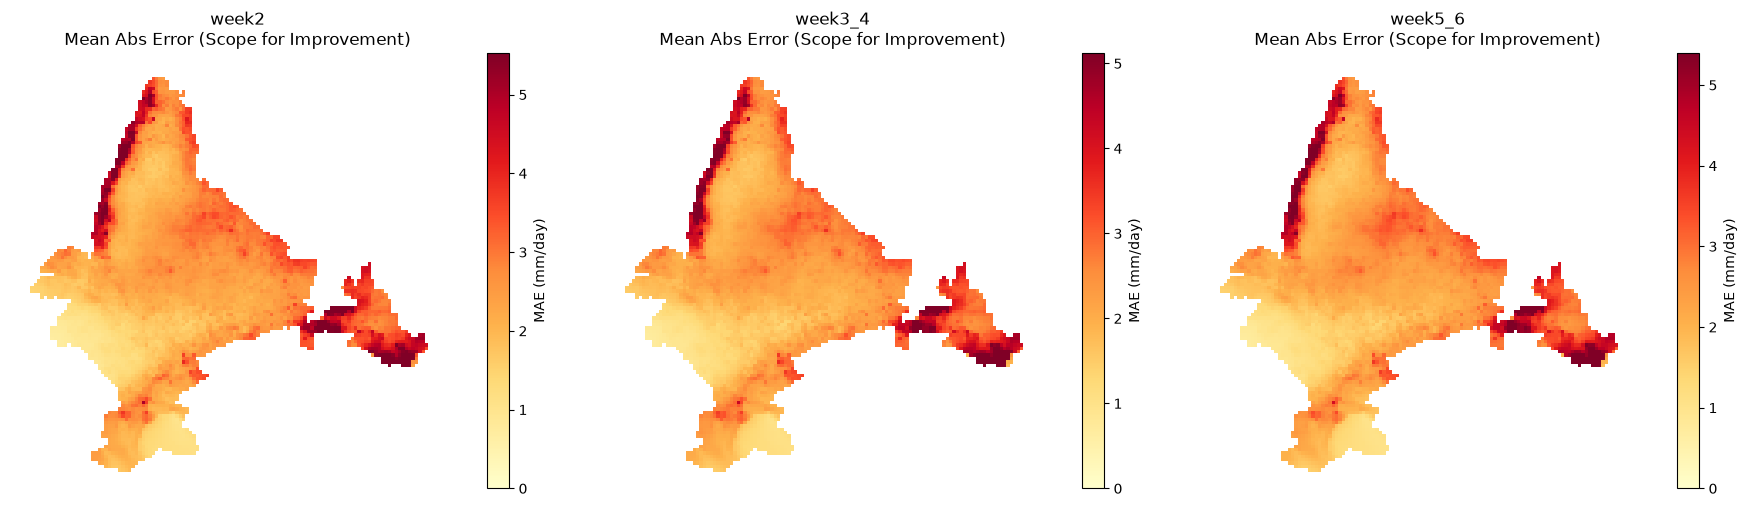

Overall Scope for Improvement (MAE over valid cells by lead window):
Window: week2      | Overall MAE: 2.5460 mm/day
Window: week3_4    | Overall MAE: 2.3574 mm/day
Window: week5_6    | Overall MAE: 2.4554 mm/day

Saved residuals to ecmwf_imd_residuals_entire_dataset.npz


In [28]:
# ==============================================================================
# SPATIAL RESIDUAL ANALYSIS (ENTIRE DATASET) BY LEAD DAY / WINDOW
# ==============================================================================
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# 1. Load data from cache
cache_file = "unet_cache_mw.npz"
z = np.load(cache_file, allow_pickle=False)
X, y, doy, wid = z["X"], z["y"], z["doy"], z["wid"]
mask, is_test = z["mask"], z["is_test"]
clat, clon = z["clat"], z["clon"]
flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
feature_vars = [str(v) for v in z["feature_vars"]]
window_names = [str(w) for w in z["window_names"]]

DTYPE = np.float32
tp_idx = feature_vars.index("total_precipitation")
fit_i = ~is_test

# 2. Climatology helper
def _clim(values, doys, window=7, n_doy=366):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    M = (np.minimum(d, n_doy - d) <= window).astype(DTYPE)
    counts = M @ np.isfinite(v2).astype(DTYPE)
    sums = M @ np.nan_to_num(v2).astype(DTYPE)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return c.reshape((n_doy,) + shp).astype(DTYPE)

# 3. Interpolate ECMWF total precipitation to fine IMD grid
tp_fine = xr.DataArray(X[:, tp_idx], dims=("s", "lat", "lon"),
                       coords={"lat": clat, "lon": clon}
                       ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)

# 4. Compute anomalies (relative to train climatology)
obs_a = y - _clim(y[fit_i], doy[fit_i])[doy - 1]
ecm_a = tp_fine - _clim(tp_fine[fit_i], doy[fit_i])[doy - 1]

# 5. Calculate Residuals: ECMWF Anomaly - Observed Anomaly
# Using the entire dataset (train + test)
residuals = ecm_a - obs_a # Shape: (samples, H, W)

# 6. Analyze Mean Absolute Error (MAE) for each cell for each lead day
n_win = len(window_names)
H, W = len(flat_lat), len(flat_lon)

fig, axes = plt.subplots(1, n_win, figsize=(6 * n_win, 5))
if n_win == 1: axes = [axes]

for w_idx in range(n_win):
    sel = (wid == w_idx)
    res_w = residuals[sel] # residuals for this lead day/window
    
    # Calculate MAE for each cell
    mae_cell = np.nanmean(np.abs(res_w), axis=0)
    mae_cell = np.where(mask, mae_cell, np.nan)
    
    ax = axes[w_idx]
    valid_mae = mae_cell[np.isfinite(mae_cell)]
    vmax = np.percentile(valid_mae, 98) if len(valid_mae) > 0 else 10
    
    im = ax.imshow(mae_cell, cmap="YlOrRd", vmin=0, vmax=vmax)
    ax.set_title(f"{window_names[w_idx]}\nMean Abs Error (Scope for Improvement)")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MAE (mm/day)")

plt.tight_layout()
plt.savefig("scope_for_improvement_mae.png", dpi=150)
plt.show()

print("Overall Scope for Improvement (MAE over valid cells by lead window):")
for w_idx in range(n_win):
    sel = (wid == w_idx)
    res_w = residuals[sel]
    valid_res = res_w[:, mask]
    valid_res = valid_res[np.isfinite(valid_res)]
    overall_mae = np.mean(np.abs(valid_res))
    print(f"Window: {window_names[w_idx]:<10} | Overall MAE: {overall_mae:.4f} mm/day")
    
# Save the residual array if needed for further analysis
np.savez_compressed("ecmwf_imd_residuals_entire_dataset.npz", residuals=residuals, wid=wid, mask=mask, window_names=window_names)
print("\nSaved residuals to ecmwf_imd_residuals_entire_dataset.npz")


In [29]:
import numpy as np

# Load the npz file
data = np.load("ecmwf_imd_residuals_entire_dataset.npz")

# See what arrays are stored inside
print("Arrays in this file:", data.files)

# Print out the shape and a few values for each array
for key in data.files:
    arr = data[key]
    print(f"\n--- Array Name: '{key}' ---")
    print("Shape:", arr.shape)
    print("Data type:", arr.dtype)
    
    # Print a few sample values (flattened to make it easier to view)
    print("Sample values:", arr.flatten()[:10])


Arrays in this file: ['residuals', 'wid', 'mask', 'window_names']

--- Array Name: 'residuals' ---
Shape: (11160, 129, 135)
Data type: float32
Sample values: [nan nan nan nan nan nan nan nan nan nan]

--- Array Name: 'wid' ---
Shape: (11160,)
Data type: int64
Sample values: [0 0 0 0 0 0 0 0 0 0]

--- Array Name: 'mask' ---
Shape: (129, 135)
Data type: bool
Sample values: [False False False False False False False False False False]

--- Array Name: 'window_names' ---
Shape: (3,)
Data type: <U7
Sample values: ['week2' 'week3_4' 'week5_6']


In [34]:
import xarray as xr
import numpy as np

# 1. Use the IMD dataset to get the correct 129x135 grid coordinates
ds_ref = xr.open_dataset("IMD_rainfall_0p25.nc") 

# 2. Load the npz file
data = np.load("ecmwf_imd_residuals_entire_dataset.npz")
residuals = data[data.files[0]]

# 3. Create the DataArray using 'sample' for time and the IMD lat/lon
da_residuals = xr.DataArray(
    data=residuals,
    dims=["sample", "lat", "lon"], 
    coords={
        "sample": np.arange(residuals.shape[0]), # 0 to 11159
        "lat": ds_ref.lat.values,                # This is length 129
        "lon": ds_ref.lon.values                 # This is length 135
    },
    name="residuals"
)

# 4. Save to NetCDF
da_residuals.to_netcdf("ecmwf_imd_residuals_entire_dataset.nc")
print("Saved successfully!")


Saved successfully!


In [2]:
ds_ecm = xr.open_zarr("s2s_reforecast_sorted.zarr")
zarr_to_netcdf("s2s_reforecast_sorted.zarr", 's2s_reforecast_sorted.nc')

Loading Zarr store from: s2s_reforecast_sorted.zarr
Saving to NetCDF: s2s_reforecast_sorted.nc
Conversion completed successfully!


In [79]:
ds = xr.open_dataset('/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_final.nc')

In [80]:
print(ds["total_precipitation"].isel(step=0).isnull().all().item())


False


In [81]:
ds = ds.isel(step=slice(1, None))

In [82]:
print(ds.step.values)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [83]:
print(ds)
print(ds["total_precipitation"].isel(time=0, step=0).values)

<xarray.Dataset> Size: 15GB
Dimensions:                   (time: 3720, step: 42, lat: 33, lon: 35)
Coordinates:
  * time                      (time) datetime64[ns] 30kB 2005-01-01 ... 2024-...
  * step                      (step) int64 336B 1 2 3 4 5 6 ... 38 39 40 41 42
  * lat                       (lat) float64 264B 38.5 37.5 36.5 ... 8.5 7.5 6.5
  * lon                       (lon) float64 280B 66.5 67.5 68.5 ... 99.5 100.5
Data variables: (12/21)
    10m_u_component_of_wind   (time, step, lat, lon) float32 722MB ...
    10m_v_component_of_wind   (time, step, lat, lon) float32 722MB ...
    2m_temperature            (time, step, lat, lon) float32 722MB ...
    mean_sea_level_pressure   (time, step, lat, lon) float32 722MB ...
    specific_humidity_1000    (time, step, lat, lon) float32 722MB ...
    specific_humidity_200     (time, step, lat, lon) float32 722MB ...
    ...                        ...
    u_component_of_wind_500   (time, step, lat, lon) float32 722MB ...
    u_compone

In [89]:
ds2 = xr.open_dataset('/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_final.nc')
print(ds2)
print(ds2["total_precipitation"].isel(time=0, step=0).values)

<xarray.Dataset> Size: 16GB
Dimensions:                   (time: 3720, step: 43, lat: 33, lon: 35)
Coordinates:
  * time                      (time) datetime64[ns] 30kB 2005-01-01 ... 2024-...
  * step                      (step) int64 344B 0 1 2 3 4 5 ... 38 39 40 41 42
  * lat                       (lat) float64 264B 38.5 37.5 36.5 ... 8.5 7.5 6.5
  * lon                       (lon) float64 280B 66.5 67.5 68.5 ... 99.5 100.5
Data variables: (12/21)
    10m_u_component_of_wind   (time, step, lat, lon) float32 739MB ...
    10m_v_component_of_wind   (time, step, lat, lon) float32 739MB ...
    2m_temperature            (time, step, lat, lon) float32 739MB ...
    mean_sea_level_pressure   (time, step, lat, lon) float32 739MB ...
    specific_humidity_1000    (time, step, lat, lon) float32 739MB ...
    specific_humidity_200     (time, step, lat, lon) float32 739MB ...
    ...                        ...
    u_component_of_wind_500   (time, step, lat, lon) float32 739MB ...
    u_compone

In [24]:
import xarray as xr
import numpy as np

# Open the dataset
ds = xr.open_dataset("s2s_reforecast_sorted.nc")

# Extract total precipitation for the first 10 dates (time) at step 0
tp_subset = ds['total_precipitation'].isel(time=slice(0, 1000), step=0)

# Extract underlying numpy array
tp_values = tp_subset.values

# Filter for non-NaN values
non_nan_values = tp_values[~np.isnan(tp_values)]

# Print the non-NaN values
print(non_nan_values)


[0. 0. 0. ... 0. 0. 0.]


In [85]:
import xarray as xr

# Open the dataset
ds = xr.open_dataset("s2s_reforecast_sorted.nc")

# Remove the first step (index 0) from the dataset
ds_filtered = ds.isel(step=slice(1, None))

# You can check the new step values to confirm step 0 is gone
print("Remaining steps:", ds_filtered.step.values)

# If you want to check the precipitation values again for the first 10 dates (now starting at what was previously step 1)
tp_subset = ds_filtered['total_precipitation'].isel(time=slice(0, 10), step=0)
tp_values = tp_subset.values
print("Non-NaN values at new first step:")
print(tp_values[~np.isnan(tp_values)])


FileNotFoundError: [Errno 2] No such file or directory: '/Users/abhimanyu/Desktop/s2s/notebooks/s2s_reforecast_sorted.nc'

In [27]:
ds.to_netcdf('s2s_reforecast_final.nc')

In [ ]:
# ======================================================================
# RESIDUAL DISTRIBUTION ANALYSIS (All Test Samples & Grid Cells)
# ======================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load predictions and cache
PRED = "unet_mw_grad_pred.npz"
CACHE = "unet_cache_mw.npz"

if not os.path.exists(PRED):
    raise FileNotFoundError(f"Missing {PRED}. Run prediction step first.")

pr = np.load(PRED, allow_pickle=False)
pred = pr["pred"].astype(np.float32)  # (N_test, H, W) UNet predicted anomaly
obs = pr["obs"].astype(np.float32)    # (N_test, H, W) IMD observed anomaly
wid = pr["wid"]

z = np.load(CACHE, allow_pickle=False)
mask = z["mask"]                       # (H, W) valid land mask
flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
window_names = [str(w) for w in z["window_names"]]
n_win = len(window_names)

# Compute raw residuals across all points: Residual = Predicted Anomaly - Observed Anomaly
residuals = pred - obs  # Shape: (N_test, H, W)

# 2. Extract valid land cell residuals per window
records = []
spatial_bias_maps = {}

for w_idx, w_name in enumerate(window_names):
    sel_samples = (wid == w_idx)
    
    # Subset predictions and observations for this window
    res_w = residuals[sel_samples]
    obs_w = obs[sel_samples]
    
    # Apply valid mask & finite values check across all samples in this window
    valid_mask_3d = mask[None, :, :] & np.isfinite(obs_w) & np.isfinite(res_w)
    
    # Flatten valid point residuals
    valid_residuals = res_w[valid_mask_3d]
    
    for r_val in valid_residuals:
        records.append({"Window": w_name, "Residual": r_val})
        
    # Spatial mean residual (bias map) per cell
    with np.errstate(invalid="ignore"):
        mean_bias = np.nanmean(np.where(valid_mask_3d, res_w, np.nan), axis=0)
        mean_bias[~mask] = np.nan
        spatial_bias_maps[w_name] = mean_bias

df_res = pd.DataFrame(records)

# ======================================================================
# PLOTTING
# ======================================================================
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.2])

# --- Plot 1: Overlay Histogram / KDE Residual Distribution ---
ax1 = fig.add_subplot(gs[0, :2])
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for idx, w_name in enumerate(window_names):
    sub = df_res[df_res["Window"] == w_name]["Residual"]
    sns.kdeplot(sub, ax=ax1, label=f"{w_name} (std={sub.std():.2f})", color=colors[idx], lw=2)

ax1.axvline(0, color="black", linestyle="--", lw=1.5, alpha=0.7, label="Zero Error (Ideal)")
ax1.set_title("Residual Distribution (Predicted - Observed Anomaly) across All Samples & Cells", fontsize=12, fontweight="bold")
ax1.set_xlabel("Residual Anomaly (mm/day)")
ax1.set_ylabel("Density")
ax1.set_xlim(-15, 15)  # Focus on primary error distribution
ax1.legend(loc="upper right")
ax1.grid(True, linestyle=":", alpha=0.6)

# --- Plot 2: Residual Boxplot by Window ---
ax2 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df_res, x="Window", y="Residual", ax=ax2, palette=colors, showfliers=False)
ax2.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7)
ax2.set_title("Residual Spread & Median", fontsize=12, fontweight="bold")
ax2.set_ylabel("Residual Anomaly (mm/day)")
ax2.grid(True, linestyle=":", alpha=0.6)

# --- Plot 3: Spatial Bias Maps (Where is the error concentrated?) ---
ext = [flat_lon[0], flat_lon[-1], flat_lat[0], flat_lat[-1]]
for idx, w_name in enumerate(window_names):
    ax_map = fig.add_subplot(gs[1, idx])
    bias_map = spatial_bias_maps[w_name]
    
    im = ax_map.imshow(bias_map, cmap="PuOr_r", vmin=-2.0, vmax=2.0, origin="lower", extent=ext, aspect="auto")
    fig.colorbar(im, ax=ax_map, fraction=0.046, label="Mean Residual (mm/day)")
    ax_map.set_title(f"{w_name} Spatial Bias\n(Mean: {np.nanmean(bias_map[mask]):+.3f} mm/d)", fontsize=10)
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("residual_distribution_analysis.png", dpi=150)
plt.show()

# ======================================================================
# SUMMARY STATISTICS TABLE
# ======================================================================
print("======================================================================")
print(f"{'Window':<10} | {'Mean Bias':<10} | {'Median':<8} | {'Std Dev':<8} | {'RMSE':<8} | {'Skewness':<8}")
print("----------------------------------------------------------------------")
for w_name in window_names:
    sub = df_res[df_res["Window"] == w_name]["Residual"]
    mean_b = sub.mean()
    med_b = sub.median()
    std_b = sub.std()
    rmse = np.sqrt((sub ** 2).mean())
    skew = sub.skew()
    print(f"{w_name:<10} | {mean_b:<+10.4f} | {med_b:<+8.4f} | {std_b:<8.4f} | {rmse:<8.4f} | {skew:<+8.4f}")
print("======================================================================")


In [ ]:
# ======================================================================
# RESIDUAL DISTRIBUTION: ECMWF vs UNet vs IMD
# ======================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xarray as xr

# 1. Load predictions (UNet & IMD) and cache (ECMWF & coords)
PRED = "unet_mw_grad_pred.npz"
CACHE = "unet_cache_mw.npz"
CLIM_WINDOW_DAYS = 7

pr = np.load(PRED, allow_pickle=False)
unet_a = pr["pred"].astype(np.float32)  # UNet predicted anomaly (N_test, H, W)
obs_a = pr["obs"].astype(np.float32)    # IMD observed anomaly (N_test, H, W)
wid_te = pr["wid"]

z = np.load(CACHE, allow_pickle=False)
X, y, doy = z["X"], z["y"], z["doy"]
mask, is_test = z["mask"], z["is_test"]
clat, clon = z["clat"], z["clon"]
flat_lat, flat_lon = z["flat_lat"], z["flat_lon"]
feature_vars = [str(v) for v in z["feature_vars"]]
window_names = [str(w) for w in z["window_names"]]

# 2. Extract and anomaly-correct raw ECMWF precipitation
def _clim(values, doys, window=CLIM_WINDOW_DAYS, n_doy=366):
    shp = values.shape[1:]
    v2 = values.reshape(len(values), -1)
    centers = np.arange(1, n_doy + 1)
    d = np.abs(doys[None, :].astype(int) - centers[:, None])
    M = (np.minimum(d, n_doy - d) <= window).astype(np.float32)
    counts = M @ np.isfinite(v2).astype(np.float32)
    sums = M @ np.nan_to_num(v2).astype(np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
    return c.reshape((n_doy,) + shp).astype(np.float32)

fit_i = ~is_test
tp_idx = feature_vars.index("total_precipitation")

# Interpolate ECMWF to fine IMD grid
tp_fine = xr.DataArray(X[:, tp_idx], dims=("s", "lat", "lon"),
                       coords={"lat": clat, "lon": clon}
                       ).interp(lat=flat_lat, lon=flat_lon).values.astype(np.float32)

# ECMWF Anomaly = ECMWF - ECMWF Climatology
ecm_clim = _clim(tp_fine[fit_i], doy[fit_i])[doy - 1]
ecm_a = (tp_fine - ecm_clim)[is_test]  # (N_test, H, W)

# 3. Compute Residuals: Model - IMD Truth
res_ecm = ecm_a - obs_a   # ECMWF Residual
res_unet = unet_a - obs_a # UNet Residual

# 4. Extract valid data points for plotting
records = []
m3 = mask[None, :, :]
fin_mask = m3 & np.isfinite(obs_a) & np.isfinite(res_ecm) & np.isfinite(res_unet)

for w_idx, w_name in enumerate(window_names):
    sel = (wid_te == w_idx)
    mask_w = fin_mask[sel]
    
    e_residuals = res_ecm[sel][mask_w]
    u_residuals = res_unet[sel][mask_w]
    
    for r in e_residuals:
        records.append({"Window": w_name, "Model": "ECMWF", "Residual": r})
    for r in u_residuals:
        records.append({"Window": w_name, "Model": "UNet", "Residual": r})

df_res = pd.DataFrame(records)

# 5. Plot Residual Distributions
fig, axes = plt.subplots(1, len(window_names), figsize=(16, 5), sharey=True)
palette = {"ECMWF": "#888888", "UNet": "#E45756"}

for idx, w_name in enumerate(window_names):
    ax = axes[idx]
    sub = df_res[df_res["Window"] == w_name]
    
    sns.kdeplot(data=sub, x="Residual", hue="Model", ax=ax, palette=palette, common_norm=False, lw=2)
    ax.axvline(0, color="black", linestyle="--", alpha=0.7, label="Zero Error")
    ax.set_title(f"{w_name}\nResidual Distribution (Model - IMD)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Residual Anomaly (mm/day)")
    ax.set_xlim(-12, 12)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("Residual Error Distribution: ECMWF vs UNet (Relative to IMD Target)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("residual_comparison_ecmwf_vs_unet.png", dpi=150)
plt.show()

# 6. Print Summary Metrics
print("=========================================================================================")
print(f"{'Window':<10} | {'Model':<8} | {'Mean Bias':<10} | {'Std Dev':<8} | {'RMSE':<8} | {'MAE':<8}")
print("-----------------------------------------------------------------------------------------")
for w_name in window_names:
    for m_name in ["ECMWF", "UNet"]:
        sub = df_res[(df_res["Window"] == w_name) & (df_res["Model"] == m_name)]["Residual"]
        mean_b = sub.mean()
        std_b = sub.std()
        rmse = np.sqrt((sub ** 2).mean())
        mae = sub.abs().mean()
        print(f"{w_name:<10} | {m_name:<8} | {mean_b:<+10.4f} | {std_b:<8.4f} | {rmse:<8.4f} | {mae:<8.4f}")
print("=========================================================================================")


In [49]:
import sys
sys.path.append("..")
from scripts.xarray_utils import (
    analyze_netcdf,
    zarr_to_netcdf,
    find_missing_days,
)
import pandas as pd
import xarray as xr
ds_big = xr.open_zarr("/Users/abhimanyu/Downloads/IFS_reforecast_download-main/s2s_new_vars_sorted.zarr")
ds_imd = xr.open_zarr("IMD_rainfall_0p25.zarr")
ds_imd = ds_imd.where(ds_imd != -999)
ds_ecm = xr.open_zarr("s2s_reforecast_sorted.zarr")

# convert lead days into timedeltas
step_td = pd.to_timedelta(ds_ecm.step.values, unit="D").to_numpy()

ds_ecmv = ds_ecm.assign_coords(
    valid_time=(("time", "step"),
                ds_ecm.time.values[:, None] + step_td[None, :])
)

FileNotFoundError: /Users/abhimanyu/Desktop/s2s/notebooks/IMD_rainfall_0p25.zarr does not exist

In [50]:
ds_big

<xarray.Dataset> Size: 17GB
Dimensions:                    (time: 3720, step: 43, lat: 57, lon: 91)
Coordinates:
  * time                       (time) datetime64[ns] 30kB 2005-01-01 ... 2024...
  * step                       (step) int64 344B 0 1 2 3 4 5 ... 38 39 40 41 42
  * lat                        (lat) float64 456B 49.5 48.5 47.5 ... -5.5 -6.5
  * lon                        (lon) float64 728B 30.0 31.0 32.0 ... 119.0 120.0
    nominalTop                 float64 8B ...
Data variables:
    geopotential_height_1000   (time, step, lat, lon) float32 3GB dask.array<chunksize=(20, 43, 57, 91), meta=np.ndarray>
    geopotential_height_200    (time, step, lat, lon) float32 3GB dask.array<chunksize=(20, 43, 57, 91), meta=np.ndarray>
    geopotential_height_500    (time, step, lat, lon) float32 3GB dask.array<chunksize=(20, 43, 57, 91), meta=np.ndarray>
    geopotential_height_850    (time, step, lat, lon) float32 3GB dask.array<chunksize=(20, 43, 57, 91), meta=np.ndarray>
    top_net_thermal_radiation  (time, step, lat, lon) float32 3GB dask.array<chunksize=(20, 43, 57, 91), meta=np.ndarray>
Attributes:
    description:  S2S IFS reforecast, model version date 2025-12-31, variable...
    n_lead_time:  42
    step_range:   0 to 42

In [54]:
tntr_raw = ds_big['top_net_thermal_radiation']
rain_raw = ds_imd['rain']
tp_raw = ds_ecmv['total_precipitation']

In [55]:
def compute_anomaly_doy(da):
    """Computes anomaly by subtracting the day-of-year climatology."""
    climatology = da.groupby('time.dayofyear').mean('time')
    return da.groupby('time.dayofyear') - climatology

# Anomalise your variables
tntr_ano = compute_anomaly_doy(tntr_raw)
rain_ano = compute_anomaly_doy(rain_raw)
tp_ano = compute_anomaly_doy(tp_raw)


In [56]:
def compute_anomaly_simple(da, dim='time'):
    """Computes anomaly by subtracting the overall mean across the time dimension."""
    return da - da.mean(dim=dim)

# Anomalise your variables
tntr_ano = compute_anomaly_simple(tntr_raw)
rain_ano = compute_anomaly_simple(rain_raw)
tp_ano = compute_anomaly_simple(tp_raw)


In [62]:
tntr_ano = ds_big['top_net_thermal_radiation'] - ds_big['top_net_thermal_radiation'].mean(dim='time')
rain_ano = ds_imd['rain'] - ds_imd['rain'].mean(dim='time')
tp_ano = ds_ecm['total_precipitation'] - ds_ecm['total_precipitation'].mean(dim='time')

# Then run the partial correlation function


In [68]:
def xr_partial_correlation(x, y, z, dim='time'):
    r_xy = xr.corr(x, y, dim=dim)
    r_xz = xr.corr(x, z, dim=dim)
    r_yz = xr.corr(y, z, dim=dim)
    
    numerator = r_xy - (r_xz * r_yz)
    # Use np.clip to ensure we don't take the sqrt of a negative number
    denom_x = np.sqrt(np.clip(1 - r_xz**2, 0, None))
    denom_y = np.sqrt(np.clip(1 - r_yz**2, 0, None))
    
    pcorr = numerator / (denom_x * denom_y)
    pcorr.name = "partial_correlation"
    return pcorr


In [69]:
pcorr_result

<xarray.DataArray 'partial_correlation' (step: 43, lat: 33, lon: 0)> Size: 0B
dask.array<truediv, shape=(43, 33, 0), dtype=float64, chunksize=(43, 33, 0), chunktype=numpy.ndarray>
Coordinates:
  * step        (step) int64 344B 0 1 2 3 4 5 6 7 8 ... 35 36 37 38 39 40 41 42
  * lat         (lat) float64 264B 38.5 37.5 36.5 35.5 34.5 ... 9.5 8.5 7.5 6.5
  * lon         (lon) float64 0B 
    nominalTop  float64 8B ...
Attributes: (12/29)
    GRIB_dataType:                            cf
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    GRIB_NV:                                  0
    ...                                       ...
    GRIB_numberOfPoints:                      1155
    GRIB_paramId:                             228228
    GRIB_shortName:                           tp
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               kg m**-2
    standard_name:                            unknown

In [70]:
# This creates a grid of plots, one for each window
pcorr_result.plot(col='Window', col_wrap=4, cmap='RdBu_r', vmin=-1, vmax=1)



TypeError: No numeric data to plot.

In [71]:
print(type(pcorr_result))
print(pcorr_result.dtype if hasattr(pcorr_result, 'dtype') else "It's a Dataset")


<class 'xarray.core.dataarray.DataArray'>
float64


In [76]:
_m = np.load("/Users/abhimanyu/Desktop/s2s/data/cache/unet_cache_dual.npz")
XA, XB, y = _m["XA"], _m["XB"], _m["y"]
doy, wid = np.asarray(_m["doy"]), np.asarray(_m["wid"])
year, mask, is_test = np.asarray(_m["year"]), np.asarray(_m["mask"]), np.asarray(_m["is_test"])
flat_lat, flat_lon = np.asarray(_m["flat_lat"]), np.asarray(_m["flat_lon"])
clatA, clonA, clatB, clonB = _m["clatA"], _m["clonA"], _m["clatB"], _m["clonB"]
window_names = [str(w) for w in _m["window_names"]]

In [ ]:
# %% [markdown]
# # Probabilistic (tercile) dual-encoder — LAG-FREE
#
# All lag machinery removed: no LAG_DAYS, no _build_lag_index, no _assemble,
# no mixer, no lag axis in the cache. XA is plain (N, V, h, w).
#
# Built on the OLD, VERIFIED-WORKING implementations of _clim_grid and
# anomalise (the ones behind the +0.019 fold-0 result), NOT the refactored
# row-chunked versions — those are where the unexplained -0.086 regression
# lives, and there is no reason to inherit it.
#
# TWO HEADS:
#   tercile  (3 logits)  -> cross-entropy, scored by RPSS. The field-standard
#                           metric; what Horat & Lerch and the India U-Net
#                           paper report, so it is the only route to an
#                           external benchmark.
#   determ.  (1 value)   -> masked MSE, scored by skill/ACC. Keeps your mm/day
#                           product and stays comparable to every run so far.
#
# WHY PROBABILISTIC AT ALL: your shrinkage diagnostic showed std_ratio
# 0.15-0.33. That is not a flaw — for a forecast with correlation r the
# RMSE-optimal amplitude IS r x observed, so at ACC 0.15 the optimal
# deterministic prediction is nearly flat. MSE gave skill but no amplitude;
# the composite loss gave amplitude but negative skill. There is no good
# deterministic point on that frontier. A distribution does not have to pick
# a value, so "60% chance above normal" stays useful at ACC 0.15.
#
# CELLS THAT CHANGE: 1, 3, 4, 5, 6, 7, 8. Cells 9/10/11 need small edits
# (see cells_prob_9_11.py).


# %%
# ============ CELL 1: CONFIG ============

import gc, json, os, time
from contextlib import contextmanager
import numpy as np

DTYPE = np.float32
IMD_TARGET_VAR = "rain"

WINDOWS   = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
MONTHS    = None
COARSE_PAD = 3.0
CLIM_WINDOW_DAYS = 7
TEST_YEARS_N = 3

BIG_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
            "geopotential_height_500", "geopotential_height_850",
            "geopotential_height_1000"]

# --- model / training ---
BASE, DROP = 24, 0.2
BATCH, EPOCHS = 16, 60
LR, WD, PATIENCE, FOLDS = 2e-4, 1e-3, 10, 5

# --- heads ---
USE_TERCILE = True       # 3-class head + cross-entropy, scored by RPSS
USE_DETERM  = True       # 1-value head + masked MSE, scored by skill/ACC
W_CE, W_MSE = 1.0, 1.0   # loss weights when both heads are on
LABEL_SMOOTH = 0.0       # try 0.05 if the tercile head overconfidently collapses

TAG = "prob" + ("_t" if USE_TERCILE else "") + ("_d" if USE_DETERM else "")
CACHE    = "unet_cache_prob"
OUT_MAPS = f"unet_{TAG}.nc"

print(f"TAG={TAG} | tercile={USE_TERCILE} determ={USE_DETERM} | months={MONTHS}")


# %%
# ============ CELL 2: UTILS ============  (unchanged)

@contextmanager
def stage(name):
    print(f"[ ] {name} ...", flush=True)
    t0 = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - t0:.1f}s)", flush=True)


def normalize_step(ds, verbose=True):
    v = ds["step"].values
    if np.issubdtype(v.dtype, np.timedelta64):
        return ds
    mx = int(np.nanmax(v))
    u = "D" if mx <= 60 else ("h" if mx <= 24 * 60 else "s")
    if verbose:
        print(f"    step is {v.dtype} (max {mx}) -> units='{u}'")
    td = v.astype(np.int64).astype(f"timedelta64[{u}]").astype("timedelta64[ns]")
    return ds.assign_coords(step=("step", td))


def ensure_valid_time(ds):
    ds = normalize_step(ds)
    expected = ds["time"] + ds["step"]
    if "valid_time" in ds.coords:
        got = ds["valid_time"]
        if got.shape == expected.shape and (got.values == expected.values).all():
            return ds
        print("    WARNING: existing valid_time != time + step -> rebuilding")
        ds = ds.drop_vars("valid_time")
    return ds.assign_coords(valid_time=expected)


# %%
# ============ CELL 3: CLIMATOLOGY, ANOMALIES, TERCILES ============
# _clim_grid and anomalise_fold are the OLD verified implementations,
# character-for-character. Do not "optimise" them again without a
# side-by-side numerical check against these.

def _clim_grid(values, doys, window, cell_chunk=20000):
    """(n, ...) -> (366, ...) DOY climatology, chunked over cells only."""
    shp = values.shape[1:]
    n = len(values)
    v2 = values.reshape(n, -1)
    n_cells = v2.shape[1]
    centers = np.arange(1, 367)
    d = np.abs(doys[None, :].astype(np.int32) - centers[:, None])
    M = (np.minimum(d, 366 - d) <= window).astype(DTYPE)
    out = np.empty((366, n_cells), DTYPE)
    for a in range(0, n_cells, cell_chunk):
        b = min(a + cell_chunk, n_cells)
        blk = v2[:, a:b]
        fin = np.isfinite(blk)
        counts = M @ fin.astype(DTYPE)
        sums = M @ np.where(fin, blk, 0).astype(DTYPE)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[:, a:b] = np.where(counts > 0, sums / np.maximum(counts, 1), np.nan)
        del blk, fin, counts, sums
    return out.reshape((366,) + shp)


def anomalise_fold(X, doy, tr):
    """Anomalise + standardise ONE predictor array on train-fold years only."""
    clim = _clim_grid(X[tr], doy[tr], CLIM_WINDOW_DAYS)
    A = X - clim[doy - 1]
    m = np.nanmean(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.nanstd(A[tr], axis=(0, 2, 3), keepdims=True)
    s = np.where(s < 1e-8, 1.0, s)
    return np.nan_to_num((A - m) / s).astype(DTYPE)


def anomalise_target(y, doy, tr):
    clim = _clim_grid(y[tr], doy[tr], CLIM_WINDOW_DAYS)
    return (y - clim[doy - 1]).astype(DTYPE)


def tercile_edges(ya, tr, mask, chunk=20000):
    """Per-cell 33rd/67th percentiles of the target ANOMALY, TRAIN only.

    Per-cell, not global: a global edge would put the arid northwest
    permanently in 'below normal'. Train-only for the same leakage reason as
    the climatology — edges that saw the val years inflate RPSS.
    """
    flat = ya[tr].reshape(int(np.sum(tr)), -1)
    n_cells = flat.shape[1]
    e1 = np.full(n_cells, np.nan, DTYPE)
    e2 = np.full(n_cells, np.nan, DTYPE)
    mf = mask.reshape(-1)
    for a in range(0, n_cells, chunk):
        b = min(a + chunk, n_cells)
        valid = mf[a:b]
        if not valid.any():
            continue
        sub = flat[:, a:b][:, valid]
        idx = np.where(valid)[0] + a
        with np.errstate(invalid="ignore"):
            e1[idx] = np.nanpercentile(sub, 100 / 3, axis=0)
            e2[idx] = np.nanpercentile(sub, 200 / 3, axis=0)
    return e1.reshape(mask.shape), e2.reshape(mask.shape)


def to_tercile(ya, e1, e2):
    """(N,H,W) anomalies -> (N,H,W) int64 class in {0,1,2}. NaN -> 1 (ignored
    by the masked loss anyway, but keeps the array integer)."""
    cls = np.ones(ya.shape, np.int64)
    with np.errstate(invalid="ignore"):
        cls[ya <= e1[None]] = 0
        cls[ya > e2[None]] = 2
    return cls


# %%
# ============ CELL 4: PREPARE (lag-free) ============
# Every trace of lag machinery is gone. XA/XB are plain (N, V, h, w).

def _subset_box(ds, imd, pad):
    ds = ensure_valid_time(ds)
    for c in ("lat", "lon"):
        if ds[c].values[0] > ds[c].values[-1]:
            ds = ds.sortby(c)
    if pad is not None:
        la0, la1 = float(imd.lat.min()), float(imd.lat.max())
        lo0, lo1 = float(imd.lon.min()), float(imd.lon.max())
        ds = ds.sel(lat=slice(la0 - pad, la1 + pad), lon=slice(lo0 - pad, lo1 + pad))
    return ds


def _window_stack(sub, feature_vars, leads, lo, hi):
    from dask.diagnostics import ProgressBar
    sel = np.where((leads >= lo) & (leads <= hi))[0]
    if len(sel) == 0:
        raise ValueError(f"no leads in [{lo},{hi}]")
    with ProgressBar():
        Xw = sub.isel(step=sel).mean(dim="step").compute()
    return np.stack([Xw[v].values for v in feature_vars], axis=1).astype(DTYPE), sel


def prepare(ecmwf_ds, big_ds, imd_ds, cache_path):
    import xarray as xr
    from dask.diagnostics import ProgressBar

    imd = imd_ds[IMD_TARGET_VAR].assign_coords(
        time=imd_ds[IMD_TARGET_VAR]["time"].dt.floor("D"))
    flat_lat, flat_lon = imd["lat"].values, imd["lon"].values

    with stage("Subset both boxes"):
        subA = _subset_box(ecmwf_ds, imd, COARSE_PAD)
        subB = _subset_box(big_ds, imd, pad=None)
        varsA = list(subA.data_vars)
        missing = [v for v in BIG_VARS if v not in subB.data_vars]
        if missing:
            raise KeyError(f"BIG_VARS missing: {missing}")
        varsB = BIG_VARS
        clatA, clonA = subA["lat"].values, subA["lon"].values
        clatB, clonB = subB["lat"].values, subB["lon"].values
        leadsA = (subA["step"].values / np.timedelta64(1, "D")).astype(int)
        leadsB = (subB["step"].values / np.timedelta64(1, "D")).astype(int)
        initA, initB = subA["time"].values, subB["time"].values
        if MONTHS is not None:
            keep = np.isin(initA.astype("datetime64[M]").astype(int) % 12 + 1, MONTHS)
            subA, subB = subA.isel(time=keep), subB.isel(time=keep)
            initA = initB = initA[keep]
        print(f"    A: {len(varsA)} vars {len(clatA)}x{len(clonA)} | "
              f"B: {len(varsB)} vars {len(clatB)}x{len(clonB)} | {len(initA)} inits")

    if initA.shape != initB.shape or not (initA == initB).all():
        raise ValueError("A and B have different init dates")
    for cla, clo, nm in [(clatA, clonA, "A"), (clatB, clonB, "B")]:
        if not (cla.min() <= flat_lat.min() and cla.max() >= flat_lat.max()
                and clo.min() <= flat_lon.min() and clo.max() >= flat_lon.max()):
            raise ValueError(f"IMD grid not inside box {nm}")

    XA_l, XB_l, y_l, doy_l, wid_l = [], [], [], [], []
    for wi, (wname, lo, hi) in enumerate(WINDOWS):
        with stage(f"Window {wname} (days {lo}-{hi})"):
            blkA, sel = _window_stack(subA, varsA, leadsA, lo, hi)
            blkB, _ = _window_stack(subB, varsB, leadsB, lo, hi)
            XA_l.append(blkA); XB_l.append(blkB)
            vt = subA["valid_time"].isel(step=sel).dt.floor("D").values
            with ProgressBar():
                y_all = imd.reindex(time=vt.ravel()).astype(DTYPE).compute().values
            y_l.append(np.nanmean(y_all.reshape(vt.shape + y_all.shape[1:]), axis=1))
            del y_all
            centre = initA + np.timedelta64((lo + hi) // 2, "D")
            doy_l.append(xr.DataArray(centre, dims="t").dt.dayofyear.values)
            wid_l.append(np.full(len(initA), wi, np.int64))
            gc.collect()

    XA = np.concatenate(XA_l); del XA_l
    XB = np.concatenate(XB_l); del XB_l
    y = np.concatenate(y_l); doy = np.concatenate(doy_l); wid = np.concatenate(wid_l)
    year = np.tile(initA.astype("datetime64[Y]").astype(int) + 1970, len(WINDOWS))
    gc.collect()

    with stage("Mask + test holdout + cache"):
        mask = np.isfinite(y).all(axis=0)
        uy = np.unique(year)
        is_test = np.isin(year, list(uy[-TEST_YEARS_N:]))
        print(f"    XA {XA.shape} {XA.nbytes/1e9:.2f} GB | XB {XB.shape} "
              f"{XB.nbytes/1e9:.2f} GB | mask {int(mask.sum())} cells")
        print(f"    test years {sorted(uy[-TEST_YEARS_N:])}")
        os.makedirs(cache_path, exist_ok=True)
        np.save(f"{cache_path}/XA.npy", XA)
        np.save(f"{cache_path}/XB.npy", XB)
        np.save(f"{cache_path}/y.npy", y)
        np.savez(f"{cache_path}/meta.npz", doy=doy, wid=wid, year=year,
                 mask=mask, is_test=is_test, clatA=clatA, clonA=clonA,
                 clatB=clatB, clonB=clonB, flat_lat=flat_lat, flat_lon=flat_lon,
                 varsA=np.array(varsA), varsB=np.array(varsB),
                 window_names=np.array([w[0] for w in WINDOWS]))
        tot = sum(os.path.getsize(f"{cache_path}/{f}") for f in os.listdir(cache_path))
        print(f"    {tot/1e9:.2f} GB -> {cache_path}/")


# RUN ONCE:
# prepare(ds_ecmv, ds_big, ds_imd, CACHE)


# %%
# ============ CELL 5: LOAD CACHE + GRIDS + DATASET ============

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

DEV = ("cuda" if torch.cuda.is_available()
       else "mps" if torch.backends.mps.is_available() else "cpu")

XA = np.load(f"{CACHE}/XA.npy")
XB = np.load(f"{CACHE}/XB.npy")
y  = np.load(f"{CACHE}/y.npy")
_m = np.load(f"{CACHE}/meta.npz")

doy, wid = np.asarray(_m["doy"]), np.asarray(_m["wid"])
year, mask, is_test = np.asarray(_m["year"]), np.asarray(_m["mask"]), np.asarray(_m["is_test"])
flat_lat, flat_lon = np.asarray(_m["flat_lat"]), np.asarray(_m["flat_lon"])
clatA, clonA, clatB, clonB = _m["clatA"], _m["clonA"], _m["clatB"], _m["clonB"]
window_names = [str(w) for w in _m["window_names"]]

H, W = len(flat_lat), len(flat_lon)
N_WIN = len(window_names)
C_A, C_B = XA.shape[1], XB.shape[1]      # no lag axis


def _make_samp(clat, clon):
    gy = 2 * (flat_lat - clat[0]) / (clat[-1] - clat[0]) - 1
    gx = 2 * (flat_lon - clon[0]) / (clon[-1] - clon[0]) - 1
    gyy, gxx = np.meshgrid(gy, gx, indexing="ij")
    s = np.stack([gxx, gyy], -1).astype(np.float32)[None]
    assert np.abs(s).max() <= 1.0, "fine grid outside source box"
    return torch.tensor(s).to(DEV)


SAMP_A, SAMP_B = _make_samp(clatA, clonA), _make_samp(clatB, clonB)
_lat2 = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
_lon2 = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()
STATIC = torch.tensor(np.stack([
    mask.astype(DTYPE),
    np.broadcast_to(_lat2, (H, W)).astype(DTYPE),
    np.broadcast_to(_lon2, (H, W)).astype(DTYPE)])[None]).to(DEV)


class S2SDS(Dataset):
    """Yields (xa, xb, wid, y_anom, y_class, mask). Per-sample fin, matching
    the old working code — not a precomputed constant."""
    def __init__(self, XAa, XBa, ya, ycls, idx):
        self.XAa, self.XBa, self.ya, self.ycls, self.idx = XAa, XBa, ya, ycls, idx

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        fin = (np.isfinite(self.ya[j]) & mask).astype(DTYPE)
        return (torch.from_numpy(self.XAa[j]),
                torch.from_numpy(self.XBa[j]),
                int(wid[j]),
                torch.from_numpy(np.nan_to_num(self.ya[j])),
                torch.from_numpy(self.ycls[j]),
                torch.from_numpy(fin))


print(f"device {DEV} | {len(XA)} samples | encA {C_A}ch encB {C_B}ch | "
      f"grid {H}x{W} | {int(mask.sum())} valid cells")


In [77]:
# %%
# ============ DIAGNOSTIC A: PARTIAL CORRELATION ============
# NO MODEL NEEDED. ~2 minutes. Run after cells 1-5.
#
# THE QUESTION: OLR correlates with rainfall on par with tp standalone, yet
# adding it made the model slightly worse (+0.028 -> +0.019, ACC 0.248 ->
# 0.226). Two explanations, and this cell separates them:
#
#   REDUNDANCY   OLR and tp are both convection proxies responding to the same
#                MJO/BSISO forcing. OLR's marginal correlation may be largely
#                the SAME information tp already carries -> nothing to extract,
#                and the flat result is a property of the data.
#
#   MODEL FAILURE  The information is genuinely there but the network is not
#                using it (capacity, optimisation, channel dilution).
#
# THE TEST: partial correlation of OLR with rain, CONTROLLING FOR tp.
#     r(O,R|T) = (r_OR - r_OT*r_TR) / sqrt((1-r_OT^2)(1-r_TR^2))
# If |r_partial| collapses toward 0 -> redundant, the model is not at fault.
# If it stays substantial -> the signal exists and the model is missing it.
#
# Same test is run for each geopotential level, and for tp controlling for OLR
# (the reverse direction), so you can see which field is the redundant one.

import numpy as np
import xarray as xr

CTRL_VAR = "total_precipitation"          # the control (encoder A)
TEST_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
             "geopotential_height_500", "geopotential_height_850",
             "geopotential_height_1000"]   # encoder B fields


def _to_fine(coarse_3d, clat, clon):
    """(N, h, w) on a coarse box -> (N, H, W) on the IMD grid."""
    return xr.DataArray(coarse_3d, dims=("s", "lat", "lon"),
                        coords={"lat": clat, "lon": clon}
                        ).interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE)


def _anom(fine_3d, rows):
    """Anomaly vs a climatology built on `rows` only (leakage-safe)."""
    return fine_3d - _clim_grid(fine_3d[rows], doy[rows], CLIM_WINDOW_DAYS)[doy - 1]


def _corr_cells(a, b, fin):
    """Per-cell Pearson r over the sample axis. (n,H,W) -> (H,W)."""
    with np.errstate(invalid="ignore", divide="ignore"):
        am = np.nanmean(np.where(fin, a, np.nan), axis=0)
        bm = np.nanmean(np.where(fin, b, np.nan), axis=0)
        num = np.nansum(np.where(fin, (a - am) * (b - bm), np.nan), axis=0)
        den = np.sqrt(np.nansum(np.where(fin, (a - am) ** 2, np.nan), axis=0)
                      * np.nansum(np.where(fin, (b - bm) ** 2, np.nan), axis=0))
        return np.where(den > 0, num / den, np.nan)


def _partial(r_xy, r_xz, r_zy):
    """r(X,Y | Z). Standard first-order partial correlation."""
    with np.errstate(invalid="ignore", divide="ignore"):
        den = np.sqrt((1 - r_xz ** 2) * (1 - r_zy ** 2))
        return np.where(den > 1e-9, (r_xy - r_xz * r_zy) / den, np.nan)


# ---- build the three anomaly fields once, on the fine grid ----
varsA = [str(v) for v in _m["varsA"]]
varsB = [str(v) for v in _m["varsB"]]
train_rows = ~is_test

with stage("Interpolating predictors to the IMD grid"):
    tp_a = _anom(_to_fine(XA[:, varsA.index(CTRL_VAR)], clatA, clonA), train_rows)
    rain_a = anomalise_target(y, doy, train_rows)
    test_fields = {}
    for v in TEST_VARS:
        src, cla, clo = (XB, clatB, clonB) if v in varsB else (XA, clatA, clonA)
        names = varsB if v in varsB else varsA
        test_fields[v] = _anom(_to_fine(src[:, names.index(v)], cla, clo), cla_ := cla, clo) \
            if False else _anom(_to_fine(src[:, names.index(v)], cla, clo), train_rows)

m3 = mask[None]

print(f"\n{'window':>9} {'variable':>28} {'r(V,rain)':>10} {'r(V,tp)':>9} "
      f"{'r partial':>10} {'retained':>9}")
print("-" * 82)

results = {}
for w in range(N_WIN):
    sel = wid == w
    fin = np.isfinite(rain_a[sel]) & m3
    r_tp_rain = _corr_cells(tp_a[sel], rain_a[sel], fin)
    for v in TEST_VARS:
        va = test_fields[v][sel]
        r_v_rain = _corr_cells(va, rain_a[sel], fin)
        r_v_tp = _corr_cells(va, tp_a[sel], fin)
        r_par = _partial(r_v_rain, r_v_tp, r_tp_rain)

        m_raw = np.nanmean(np.abs(r_v_rain[mask]))
        m_tp = np.nanmean(np.abs(r_v_tp[mask]))
        m_par = np.nanmean(np.abs(r_par[mask]))
        retained = m_par / m_raw if m_raw > 0 else np.nan
        results[(window_names[w], v)] = (m_raw, m_tp, m_par, retained)
        print(f"{window_names[w]:>9} {v:>28} {m_raw:>10.3f} {m_tp:>9.3f} "
              f"{m_par:>10.3f} {retained:>8.0%}")

    # reverse direction: is TP the redundant one, given OLR?
    olr = test_fields["top_net_thermal_radiation"][sel]
    r_o_rain = _corr_cells(olr, rain_a[sel], fin)
    r_tp_o = _corr_cells(tp_a[sel], olr, fin)
    r_tp_par = _partial(r_tp_rain, r_tp_o, r_o_rain)
    print(f"{window_names[w]:>9} {'tp | OLR (reverse)':>28} "
          f"{np.nanmean(np.abs(r_tp_rain[mask])):>10.3f} "
          f"{np.nanmean(np.abs(r_tp_o[mask])):>9.3f} "
          f"{np.nanmean(np.abs(r_tp_par[mask])):>10.3f} "
          f"{np.nanmean(np.abs(r_tp_par[mask]))/max(np.nanmean(np.abs(r_tp_rain[mask])),1e-9):>8.0%}")
    print()

print("HOW TO READ 'retained' (= |partial| / |raw|):")
print("  < 30%  -> mostly redundant with tp. The model is not at fault; there")
print("            is little unique information to extract. Look for genuinely")
print("            independent predictors, or accept the ceiling.")
print("  > 60%  -> the field carries substantial UNIQUE signal. The model is")
print("            failing to use it -> run Diagnostic B (permutation).")
print("  30-60% -> partial redundancy; a gain is possible but will be small.")

[ ] Interpolating predictors to the IMD grid ...
[x] Interpolating predictors to the IMD grid  (102.5s)

   window                     variable  r(V,rain)   r(V,tp)  r partial  retained
----------------------------------------------------------------------------------


NameError: name 'N_WIN' is not defined

In [73]:
# %%
# ============ DIAGNOSTIC B: PERMUTATION IMPORTANCE ============
# Needs ONE trained model. If you have a fold model in memory, pass it in;
# otherwise this trains fold 0 first (~35 min), then permutation is ~2 min.
#
# THE QUESTION: Diagnostic A tells you whether the information EXISTS.
# This tells you whether the MODEL USES IT. They are different failures and
# they have different fixes.
#
# THE TEST: shuffle one input variable across samples (destroying its link to
# the target while preserving its marginal distribution), re-predict, measure
# the ACC drop. A variable the model relies on causes a large drop. A variable
# it ignores causes none.
#
# Crucially this is measured on VALIDATION data with a FIXED model — no
# retraining — so it isolates "does the trained network read this channel"
# from "would a retrained network find it useful".

import numpy as np


def permutation_importance(model, XAa, XBa, ya, ycls, idx, n_repeat=3, seed=0):
    """Returns {(<'A'|'B'>, varname): mean ACC drop}. Larger = more used."""
    rng = np.random.default_rng(seed)
    fin = np.isfinite(np.asarray(y)[idx]) & mask[None]
    t = ya[idx]

    def _acc(det):
        _, ac = skill_acc(det, t, fin)
        return float(np.nanmean(ac[mask]))

    _, det0 = predict(model, idx, XAa, XBa, ya, ycls)
    base = _acc(det0)
    print(f"  baseline ACC on this fold: {base:.4f}\n")

    varsA = [str(v) for v in _m["varsA"]]
    varsB = [str(v) for v in _m["varsB"]]
    out = {}

    for which, arr, names in (("A", XAa, varsA), ("B", XBa, varsB)):
        for ci, nm in enumerate(names):
            drops = []
            for rep in range(n_repeat):
                saved = arr[idx, ci].copy()
                perm = rng.permutation(len(idx))
                # shuffle this channel ACROSS SAMPLES: marginal distribution
                # preserved, link to the target destroyed
                arr[idx, ci] = saved[perm]
                _, detp = predict(model, idx, XAa, XBa, ya, ycls)
                drops.append(base - _acc(detp))
                arr[idx, ci] = saved          # restore before the next repeat
            out[(which, nm)] = (float(np.mean(drops)), float(np.std(drops)))
            print(f"  {which} {nm:<30} drop {np.mean(drops):+.4f} "
                  f"+/- {np.std(drops):.4f}")
    return base, out


# ---- run it on fold 0 ----
vy = set(np.array_split(sorted(set(year[~is_test].tolist())), FOLDS)[0].tolist())
va_i = np.isin(year, list(vy)) & ~is_test
tr_i = ~np.isin(year, list(vy)) & ~is_test

with stage("Preparing fold 0 arrays"):
    XAa = anomalise_fold(XA, doy, tr_i)
    XBa = anomalise_fold(XB, doy, tr_i)
    ya = anomalise_target(y, doy, tr_i)
    e1, e2 = tercile_edges(ya, tr_i, mask)
    ycls = to_tercile(ya, e1, e2)

with stage("Training fold 0 (skip if you already have a model)"):
    model, _, eps = train_one(np.where(tr_i)[0], np.where(va_i)[0],
                              XAa, XBa, ya, ycls)
    print(f"    {eps} epochs")

with stage("Permutation importance"):
    base, imp = permutation_importance(model, XAa, XBa, ya, ycls, np.where(va_i)[0])

# ---- ranked summary ----
print(f"\n{'rank':>4} {'enc':>4} {'variable':>30} {'ACC drop':>10}")
print("-" * 52)
for i, ((wh, nm), (mu, sd)) in enumerate(
        sorted(imp.items(), key=lambda kv: -kv[1][0]), 1):
    print(f"{i:>4} {wh:>4} {nm:>30} {mu:>+10.4f}")

used = sum(1 for (mu, _) in imp.values() if mu > 0.005)
print(f"\n  {used}/{len(imp)} channels cause an ACC drop > 0.005 when shuffled")
print("\nHOW TO READ THIS:")
print("  A variable with drop ~0 is being IGNORED by the trained model.")
print("  If OLR / geopotential all sit near zero while tp dominates, the")
print("  network collapsed onto the single strongest predictor and the extra")
print("  channels are dead weight -> an OPTIMISATION/capacity problem, fixable")
print("  by architecture (separate encoders already tried), stronger")
print("  regularisation on the dominant channel, or dropping tp entirely to")
print("  force the model to use the rest.")
print("  If they DO show drops but skill still did not improve, the channels")
print("  are used but redundant -> matches Diagnostic A, and the ceiling is")
print("  in the data, not the model.")

del XAa, XBa, ya, ycls; gc.collect()

NameError: name 'year' is not defined